# HYP-0014 Performance Review

Three-year core metals flow-filtered residual mean-reversion strategy.

This notebook reviews the HYP-0014 backtest artifacts and provides performance
metrics, diagnostic plots, and signal-vs-forward-return scatterplots at both the
portfolio and individual-root levels.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

ROOTS = ["GC", "SI", "HG", "PL", "PA"]
EXP = Path(
    "/home/famadeo/quant-lab/experiments/HYP-0014-metals-flow-filtered-residual-reversion-3y"
)
PLOTS = EXP / "plots"
HORIZONS = [1, 2, 5, 10, 20, 50]
RNG = np.random.default_rng(7)

## Load Artifacts

In [2]:
with (EXP / "results.json").open("r", encoding="utf-8") as fh:
    results = json.load(fh)
summary = results["summary"]

bars = pd.read_parquet(EXP / "bars.parquet")
returns = pd.read_parquet(EXP / "returns.parquet")
residual_z = pd.read_parquet(EXP / "residual_z.parquet")
anomalies = pd.read_parquet(EXP / "anomalies.parquet")
size_disagreement = pd.read_parquet(EXP / "size_disagreement.parquet")
positions = pd.read_parquet(EXP / "positions.parquet")
raw_positions = pd.read_parquet(EXP / "raw_positions.parquet")
selected_returns = pd.read_parquet(EXP / "selected_returns.parquet")
shares = pd.read_parquet(EXP / "shares.parquet")
features = pd.read_parquet(EXP / "features.parquet")

variants = pd.read_csv(EXP / "variants.csv")
split_metrics = pd.read_csv(EXP / "split_metrics.csv")
bootstrap = pd.read_csv(EXP / "bootstrap.csv")
monthly_returns = pd.read_csv(EXP / "monthly_returns.csv")
threshold_summary = pd.read_csv(EXP / "threshold_summary.csv")
trade_inventory = pd.read_csv(EXP / "trade_inventory.csv")
cost_estimates = pd.read_csv(EXP / "cost_estimates.csv")
ic_fdr = pd.read_csv(EXP / "ic_fdr.csv")
monthly_ic = pd.read_csv(EXP / "monthly_ic.csv")

bars["end_ts"] = pd.to_datetime(bars["end_ts"], utc=True)
bars["start_ts"] = pd.to_datetime(bars["start_ts"], utc=True)
ts = bars["end_ts"]
month = ts.dt.to_period("M").astype(str)

selected_returns = selected_returns.copy()
selected_returns["ts"] = ts
selected_returns["month"] = month
selected_returns["equity"] = selected_returns["net_return"].cumsum()
selected_returns["gross_equity"] = selected_returns["gross_return"].cumsum()
selected_returns["cost_equity"] = selected_returns["cost_return"].cumsum()
selected_returns["drawdown"] = selected_returns["equity"] - selected_returns["equity"].cummax()

print(results["experiment_id"])
print(f"Rows: {len(bars):,} complete $250M bars")
print(f"Date range: {ts.min()} to {ts.max()}")

HYP-0014-metals-flow-filtered-residual-reversion-3y
Rows: 242,162 complete $250M bars
Date range: 2023-06-22 00:45:01.900427+00:00 to 2026-06-21 23:56:08.116117+00:00


/tmp/ipykernel_323675/4172033209.py:29: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  month = ts.dt.to_period("M").astype(str)


## Headline Metrics

In [3]:
headline = pd.Series(summary["selected_strategy_metrics"], name="value").to_frame()
headline.loc[
    [
        "observations",
        "active_bars",
        "gross_return",
        "cost_return",
        "net_return",
        "gross_to_cost",
        "tstat",
        "annualized_sharpe",
        "max_drawdown",
        "turnover",
        "mean_net_bps",
    ]
]

,value
observations,242162.000000
active_bars,33646.000000
gross_return,4.026673
cost_return,0.356518
net_return,3.670155
gross_to_cost,11.294454
tstat,9.019133
annualized_sharpe,5.206611
max_drawdown,-0.074999
turnover,1527.166667


In [4]:
variants.assign(
    net_return_pct=variants["net_return"],
    max_drawdown_pct=variants["max_drawdown"],
    active_fraction=variants["active_bars"] / variants["observations"],
)[
    [
        "variant",
        "cost_multiplier",
        "net_return_pct",
        "gross_return",
        "cost_return",
        "gross_to_cost",
        "tstat",
        "annualized_sharpe",
        "max_drawdown_pct",
        "active_fraction",
        "turnover",
    ]
]

,variant,cost_multiplier,net_return_pct,gross_return,cost_return,gross_to_cost,tstat,annualized_sharpe,max_drawdown_pct,active_fraction,turnover
0,cost_0.0,0.0,4.026673,4.026673,0.000000,inf,9.860262,5.692183,-0.073719,0.13894,1527.166667
1,cost_1.0,1.0,3.670155,4.026673,0.356518,11.294454,9.019133,5.206611,-0.074999,0.13894,1527.166667
2,cost_2.0,2.0,3.313637,4.026673,0.713035,5.647227,8.167884,4.715198,-0.076280,0.13894,1527.166667
3,cost_3.0,3.0,2.957120,4.026673,1.069553,3.764818,7.307682,4.218616,-0.077561,0.13894,1527.166667


In [5]:
split_metrics[
    [
        "split",
        "observations",
        "active_bars",
        "gross_return",
        "cost_return",
        "net_return",
        "gross_to_cost",
        "tstat",
        "annualized_sharpe",
        "max_drawdown",
        "turnover",
    ]
]

,split,observations,active_bars,gross_return,cost_return,net_return,gross_to_cost,tstat,annualized_sharpe,max_drawdown,turnover
0,train,169513,7081,0.555212,0.066699,0.488512,8.324133,3.178875,2.193387,-0.074999,288.083333
1,test_embargoed,72599,26535,3.472895,0.289467,3.183429,11.997566,8.453707,8.913027,-0.064984,1238.083333


In [6]:
bootstrap

,metric,observed,bootstrap_mean,p05,p50,p95,p_positive,days,iterations
0,net_return,3.670155,3.660025,3.076027,3.641134,4.298058,1.0,934,2000


## Market Data And Bar Diagnostics

In [7]:
threshold_summary

,threshold,threshold_m,bars,bars_per_day,median_duration_seconds,mean_duration_seconds,median_trades,mean_trades,median_dominant_share,mean_hhi
0,1.000000e+08,100.0,603410,550.557384,61.888219,156.611999,240.0,254.106473,0.740692,0.601672
1,2.500000e+08,250.0,242162,220.951271,161.620855,390.715133,598.0,633.172199,0.734597,0.590190
2,5.000000e+08,500.0,121214,110.597621,330.097251,780.895757,1198.5,1264.949635,0.731281,0.583610
3,1.000000e+09,1000.0,60642,55.331100,676.067263,1561.120467,2402.0,2528.431038,0.729319,0.578356


In [8]:
trade_inventory.assign(
    notional_share=lambda df: df["notional"] / df["notional"].sum(),
    trade_share=lambda df: df["trades"] / df["trades"].sum(),
)[
    [
        "root",
        "trades",
        "trade_share",
        "notional",
        "notional_share",
        "signed_ratio",
        "median_trade_notional",
        "p99_trade_notional",
    ]
]

,root,trades,trade_share,notional,notional_share,signed_ratio,median_trade_notional,p99_trade_notional
0,GC,82365734,0.537178,4.338755e+13,0.715058,-0.001923,399060.0,2635680.0
1,SI,29540740,0.192661,1.055431e+13,0.173943,-0.001314,247950.0,1895800.0
2,HG,25318855,0.165126,5.043377e+12,0.083118,-0.002765,126212.5,1060560.5
3,PL,13719194,0.089475,1.279003e+12,0.021079,-0.003135,69405.0,415320.0
4,PA,2386009,0.015561,4.127516e+11,0.006802,-0.007528,128600.0,694050.0


In [9]:
cost_estimates

,root,rows,median_spread_bps,p75_spread_bps,median_top_depth,per_side_cost_bps,source
0,GC,41124344,1.101576,1.380326,3.0,0.550788,mbp1
1,SI,23412610,3.739017,4.665630,3.0,1.869508,mbp1
2,HG,14503067,1.600768,2.384453,4.0,0.800384,mbp1
3,PL,16496932,5.126365,6.613160,3.0,2.563182,mbp1
4,PA,2584537,11.187768,12.332991,5.0,5.593884,mbp1


## Existing Diagnostic Plots

These are the plots produced by the HYP-0014 runner.

strategy_equity_drawdown.png


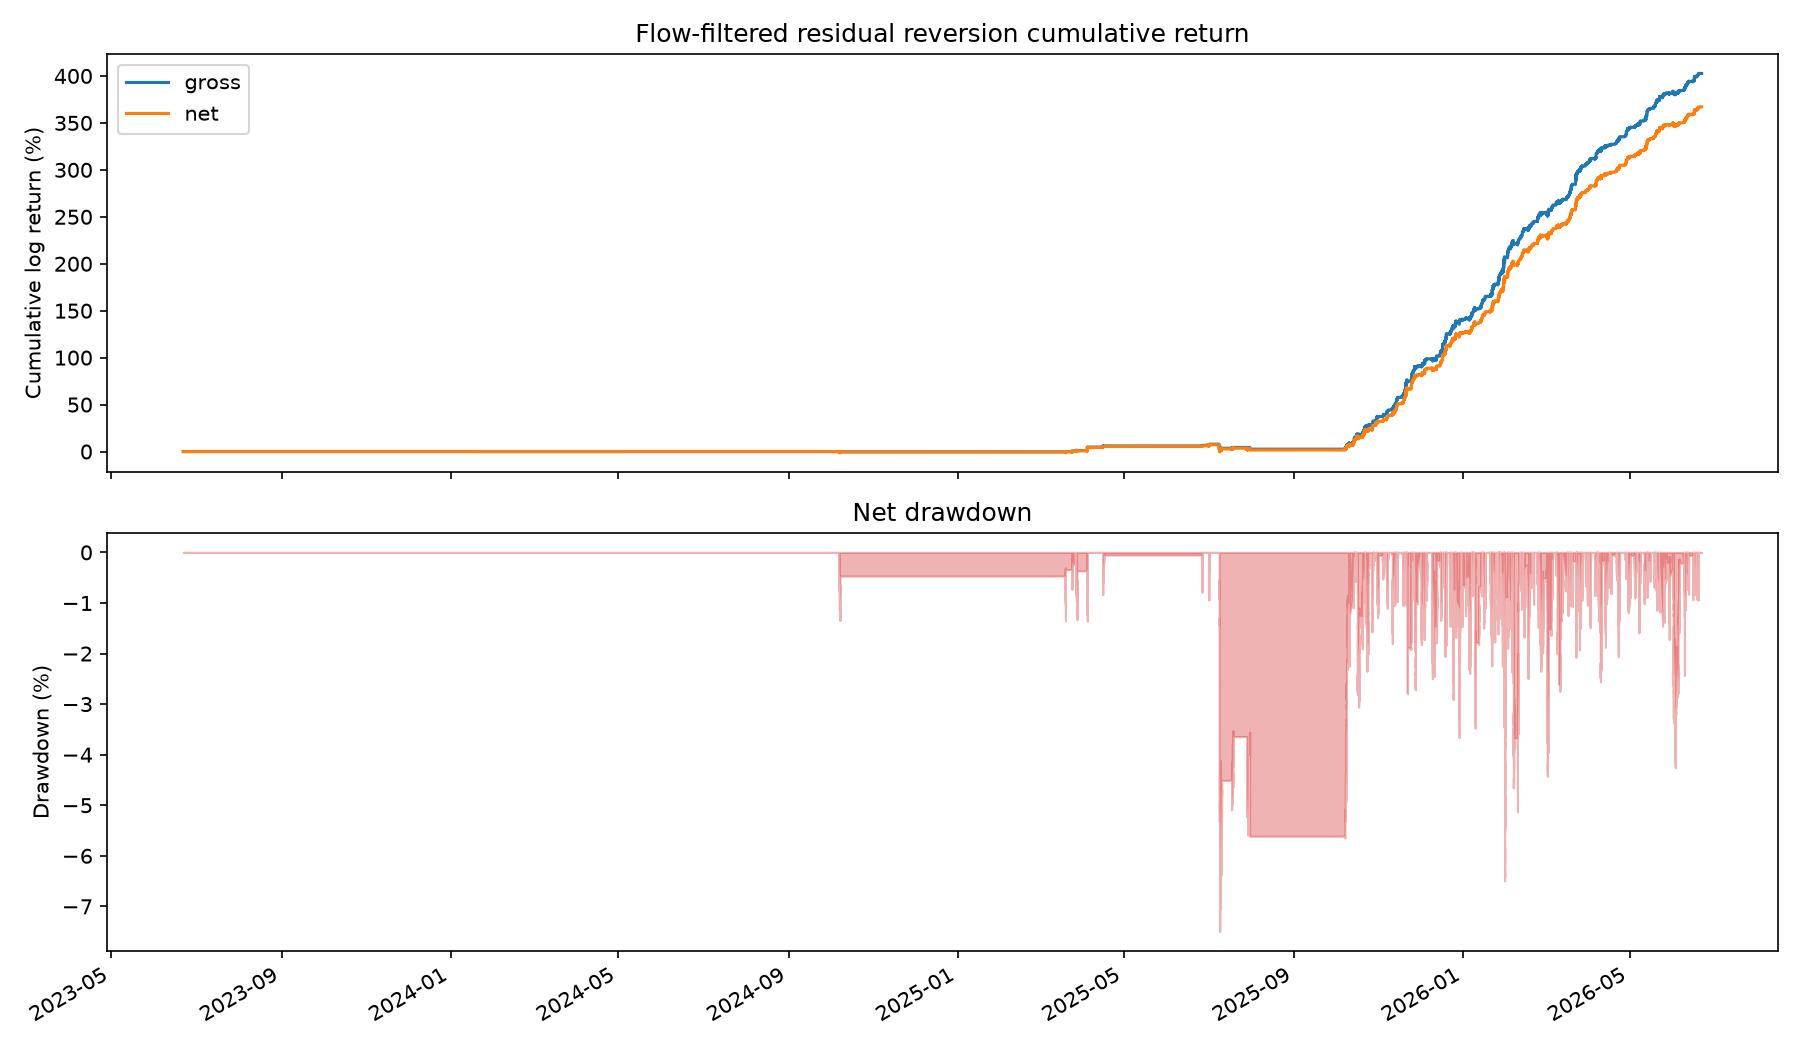

monthly_returns.png


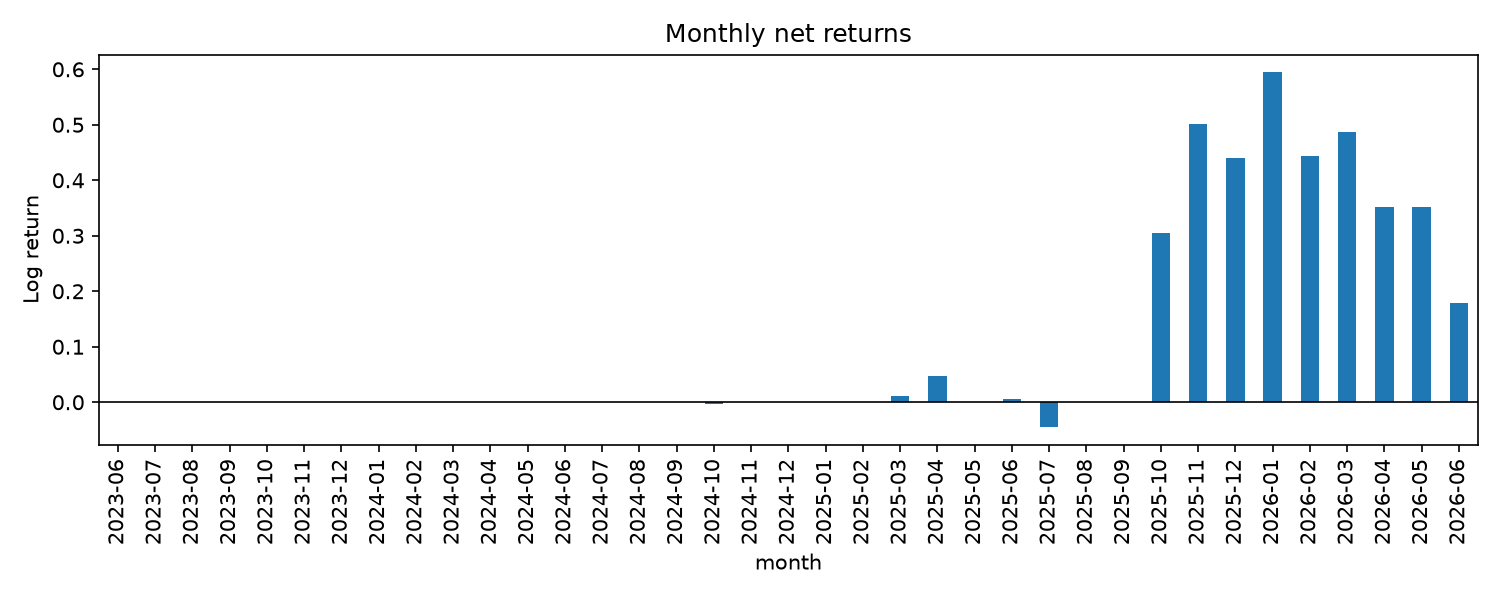

cost_sensitivity.png


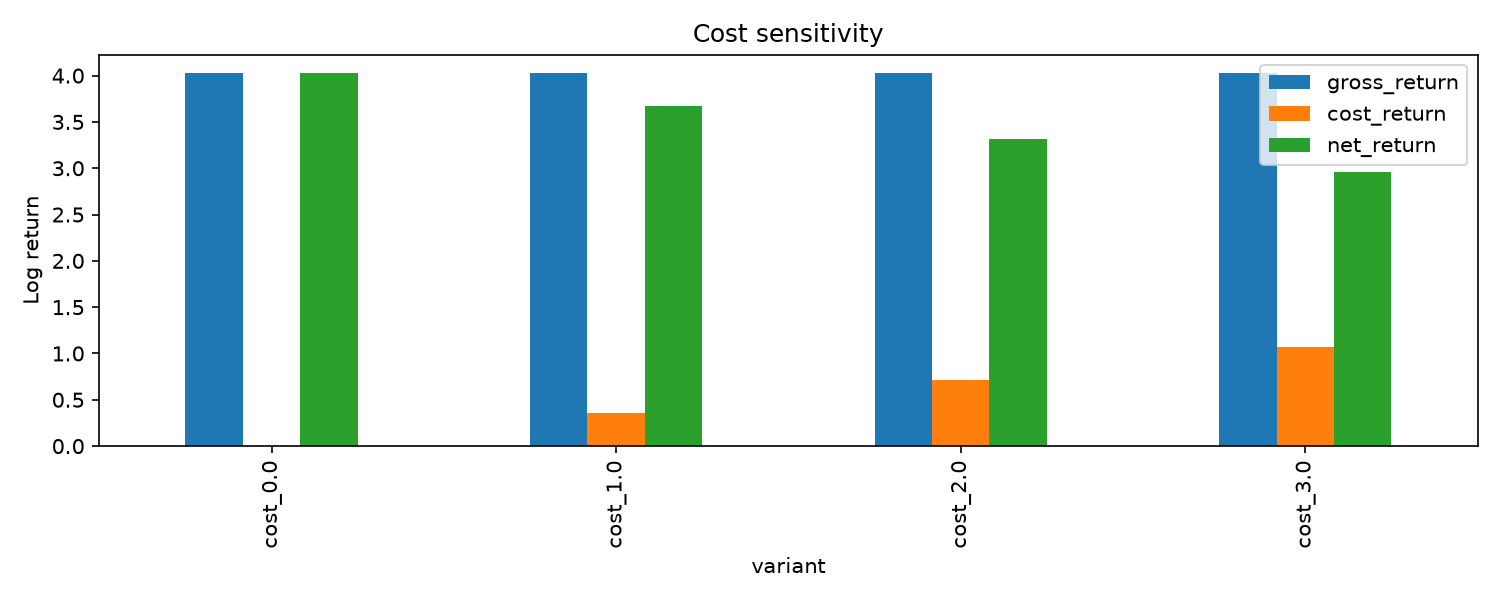

gross_exposure.png


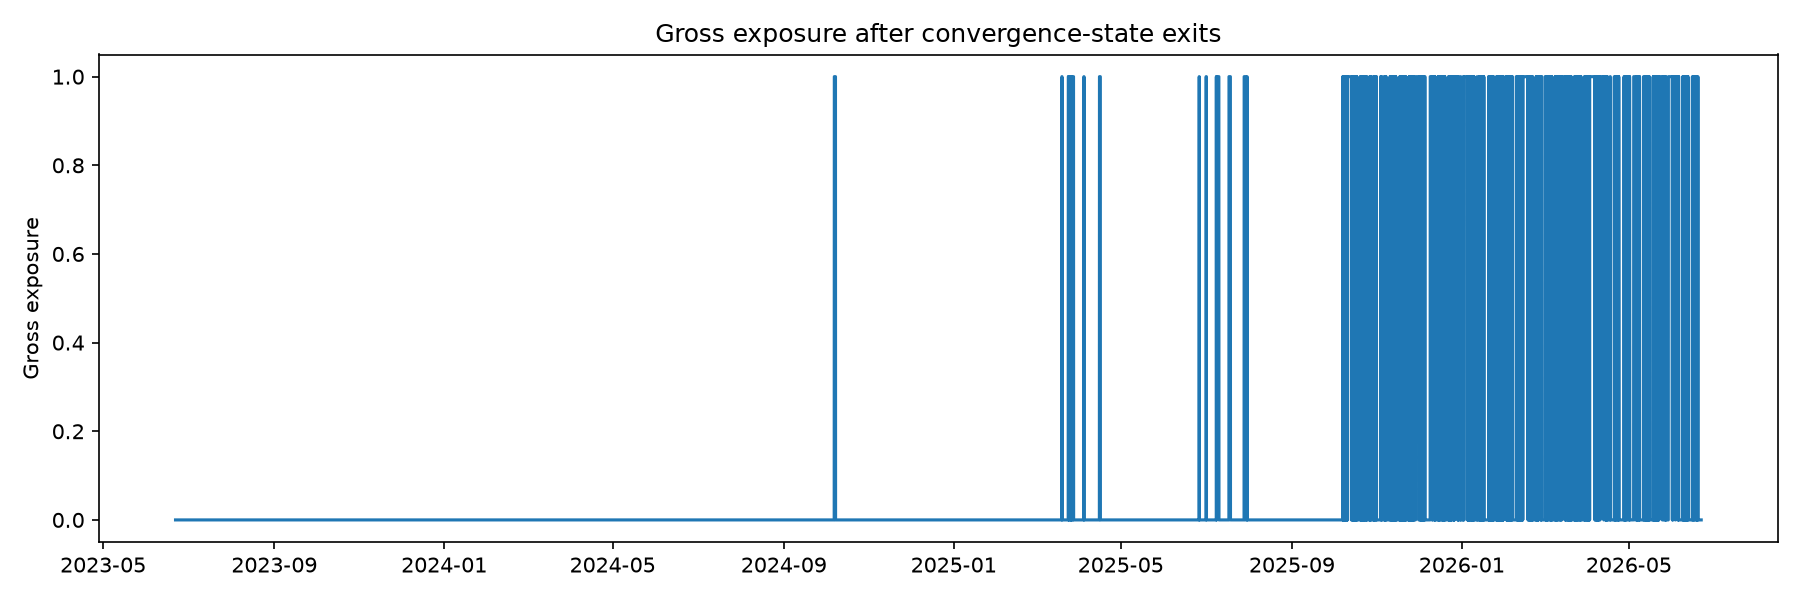

flow_filters.png


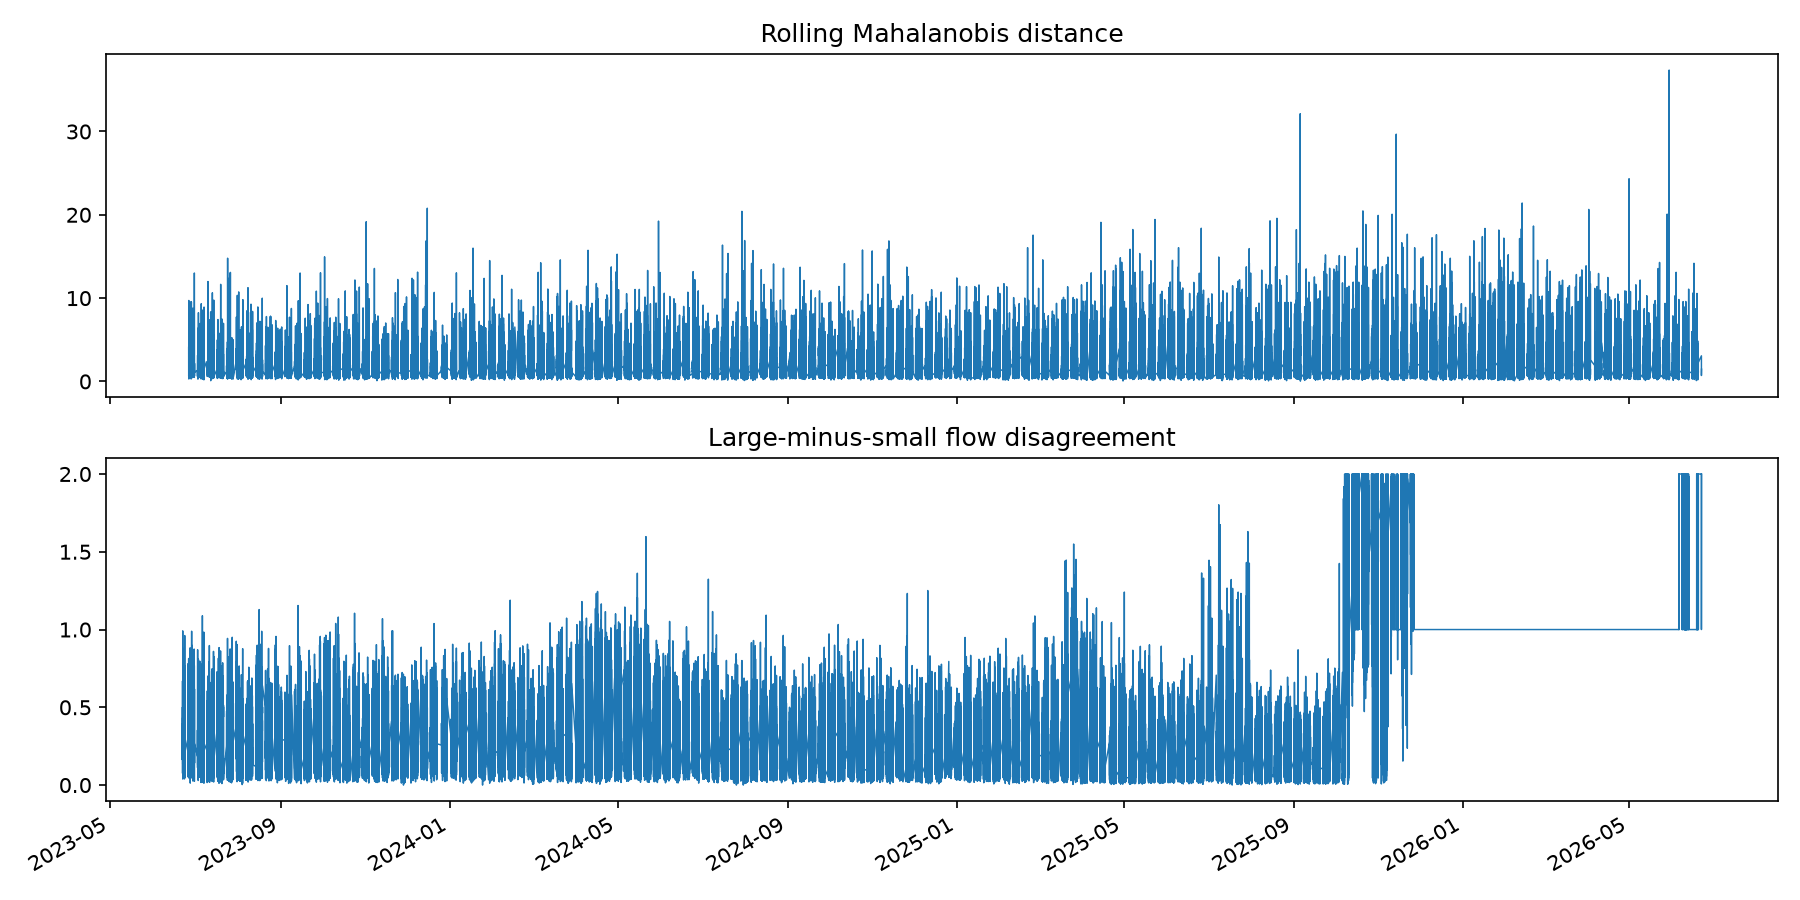

residual_zscores.png


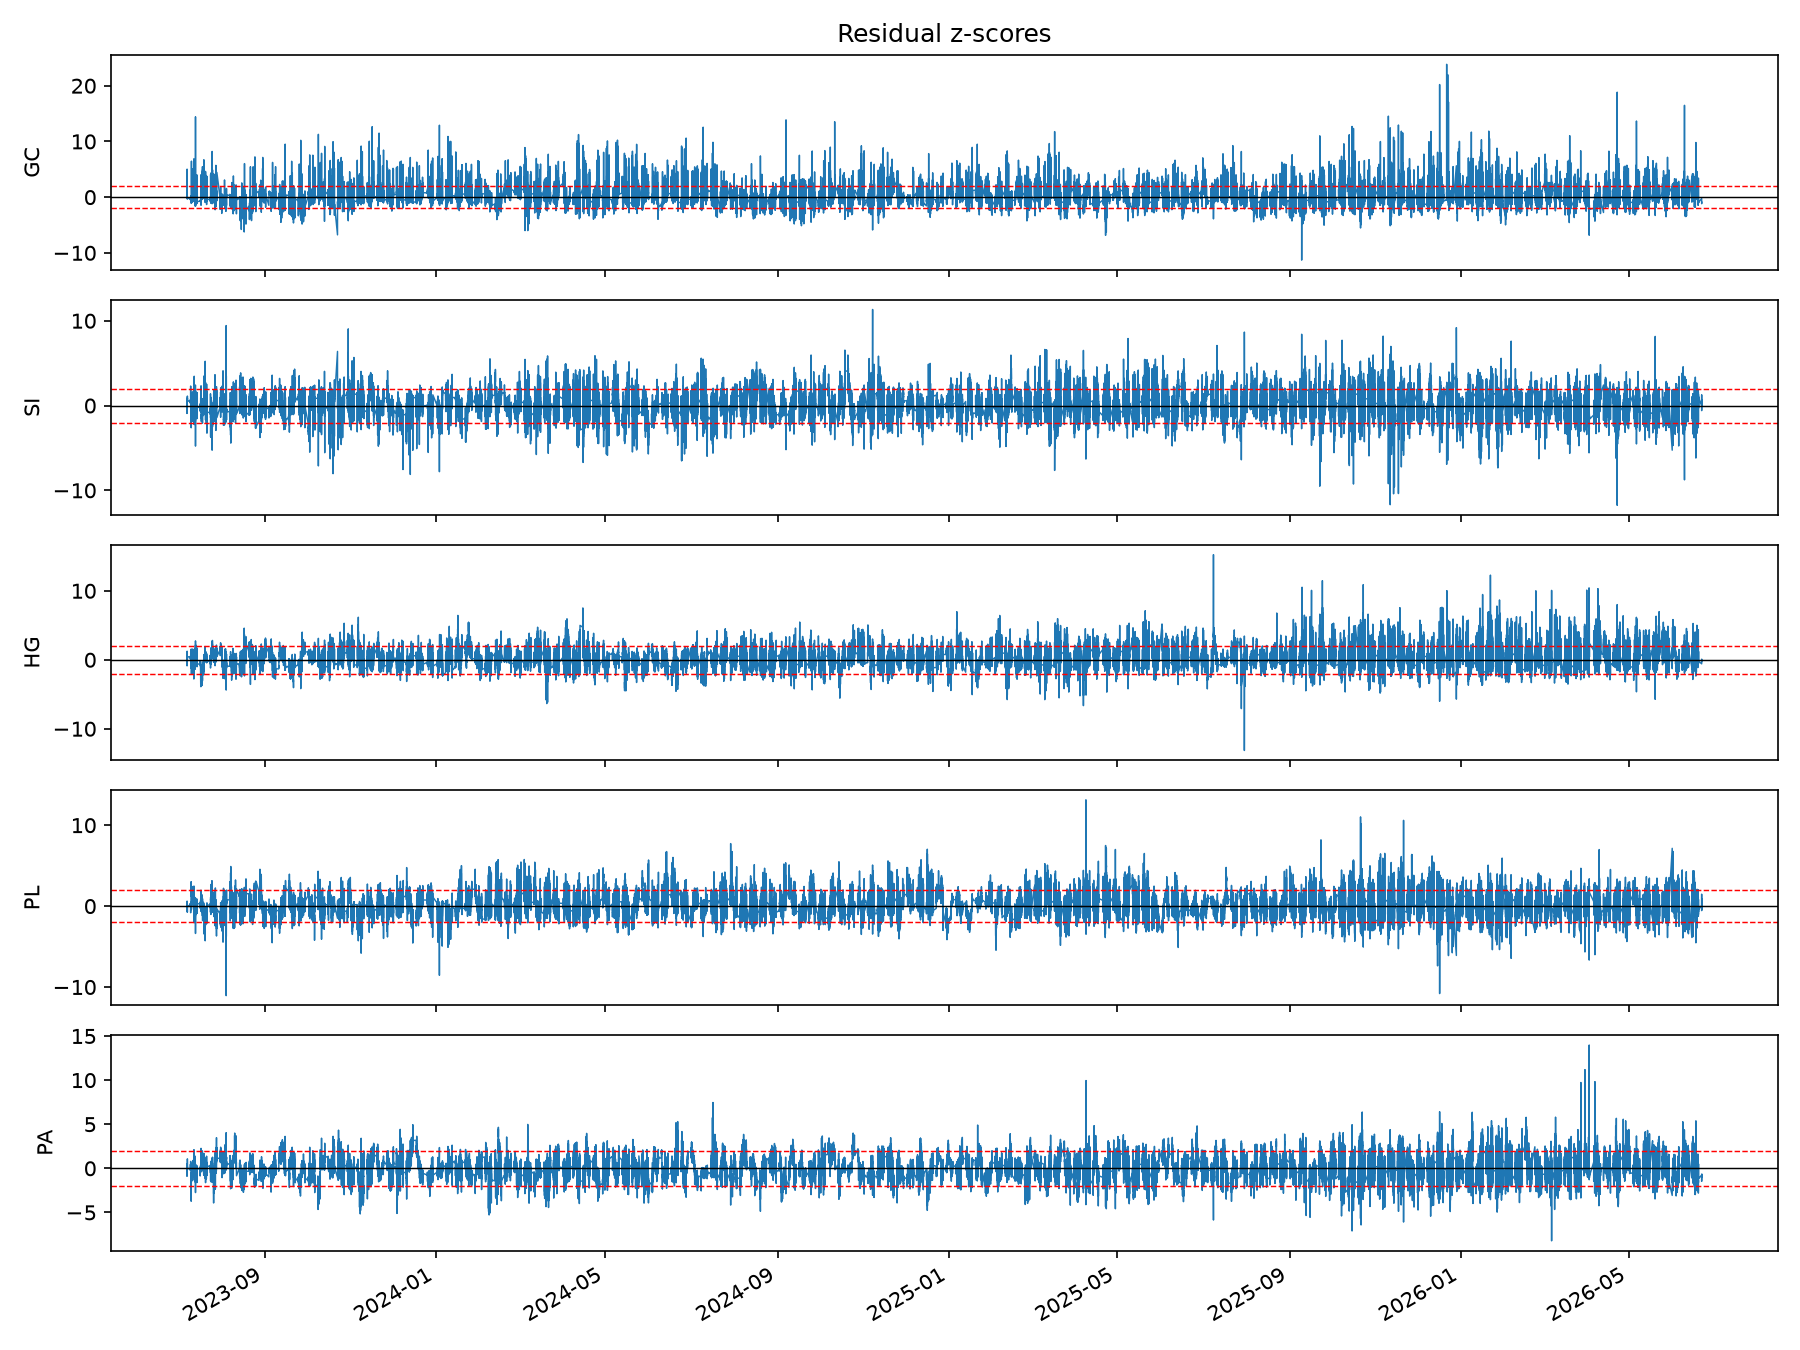

top_ic.png


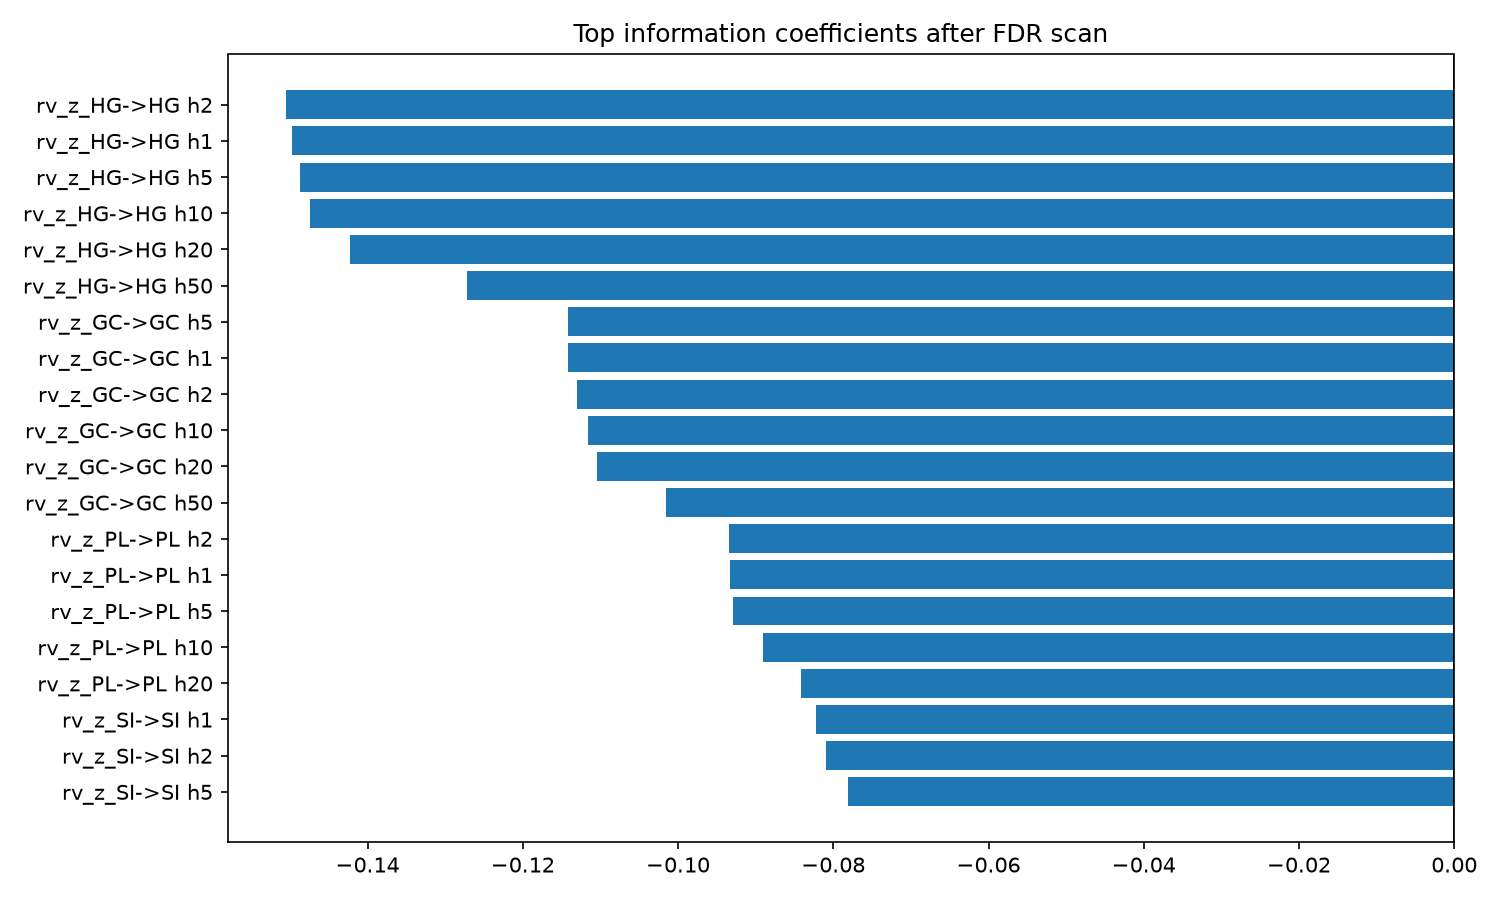

monthly_ic_heatmap.png


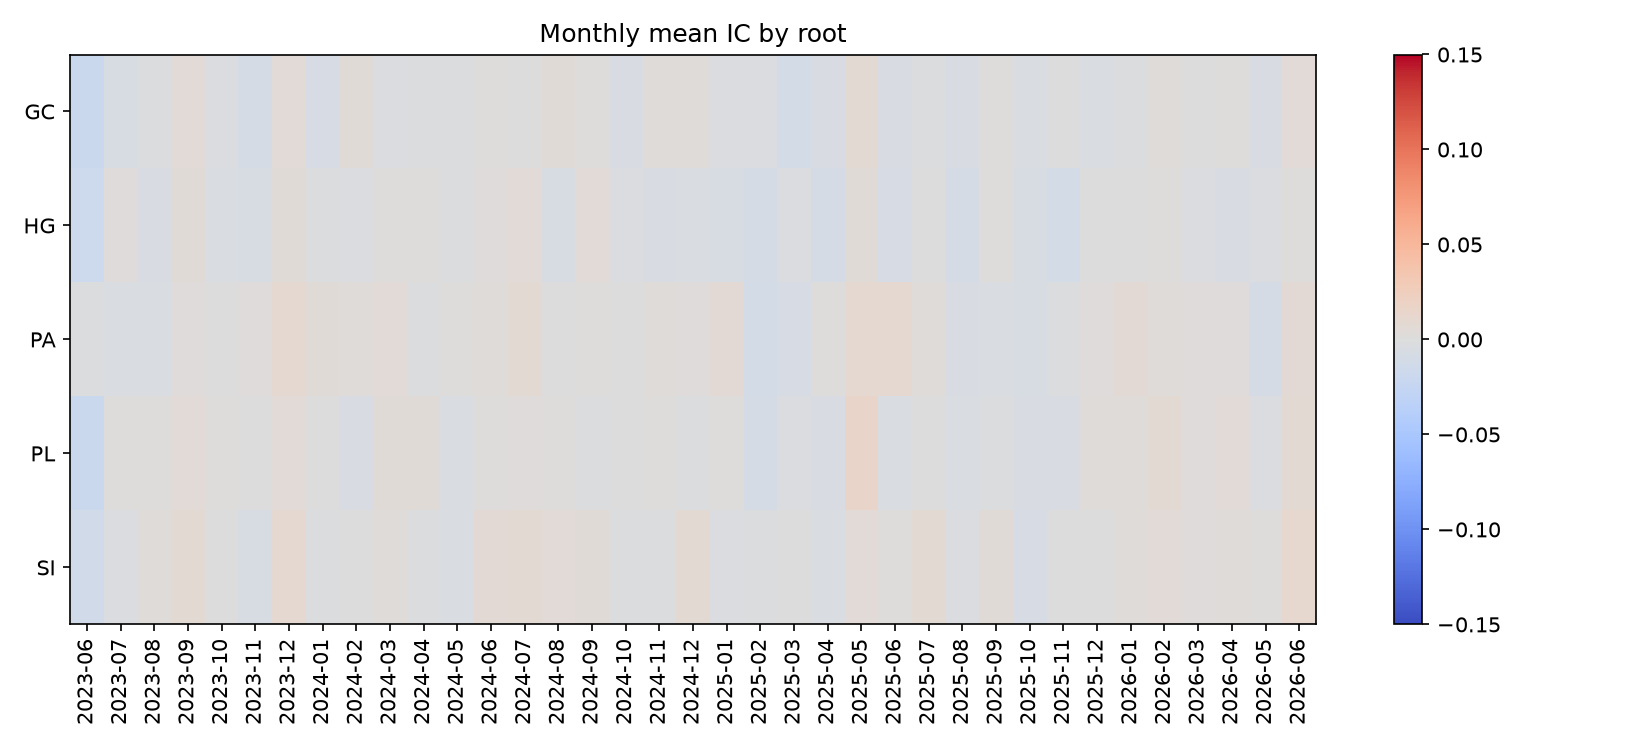

In [10]:
for name in [
    "strategy_equity_drawdown.png",
    "monthly_returns.png",
    "cost_sensitivity.png",
    "gross_exposure.png",
    "flow_filters.png",
    "residual_zscores.png",
    "top_ic.png",
    "monthly_ic_heatmap.png",
]:
    print(name)
    display(Image(filename=str(PLOTS / name)))

## Equity, Drawdown, And Monthly Attribution

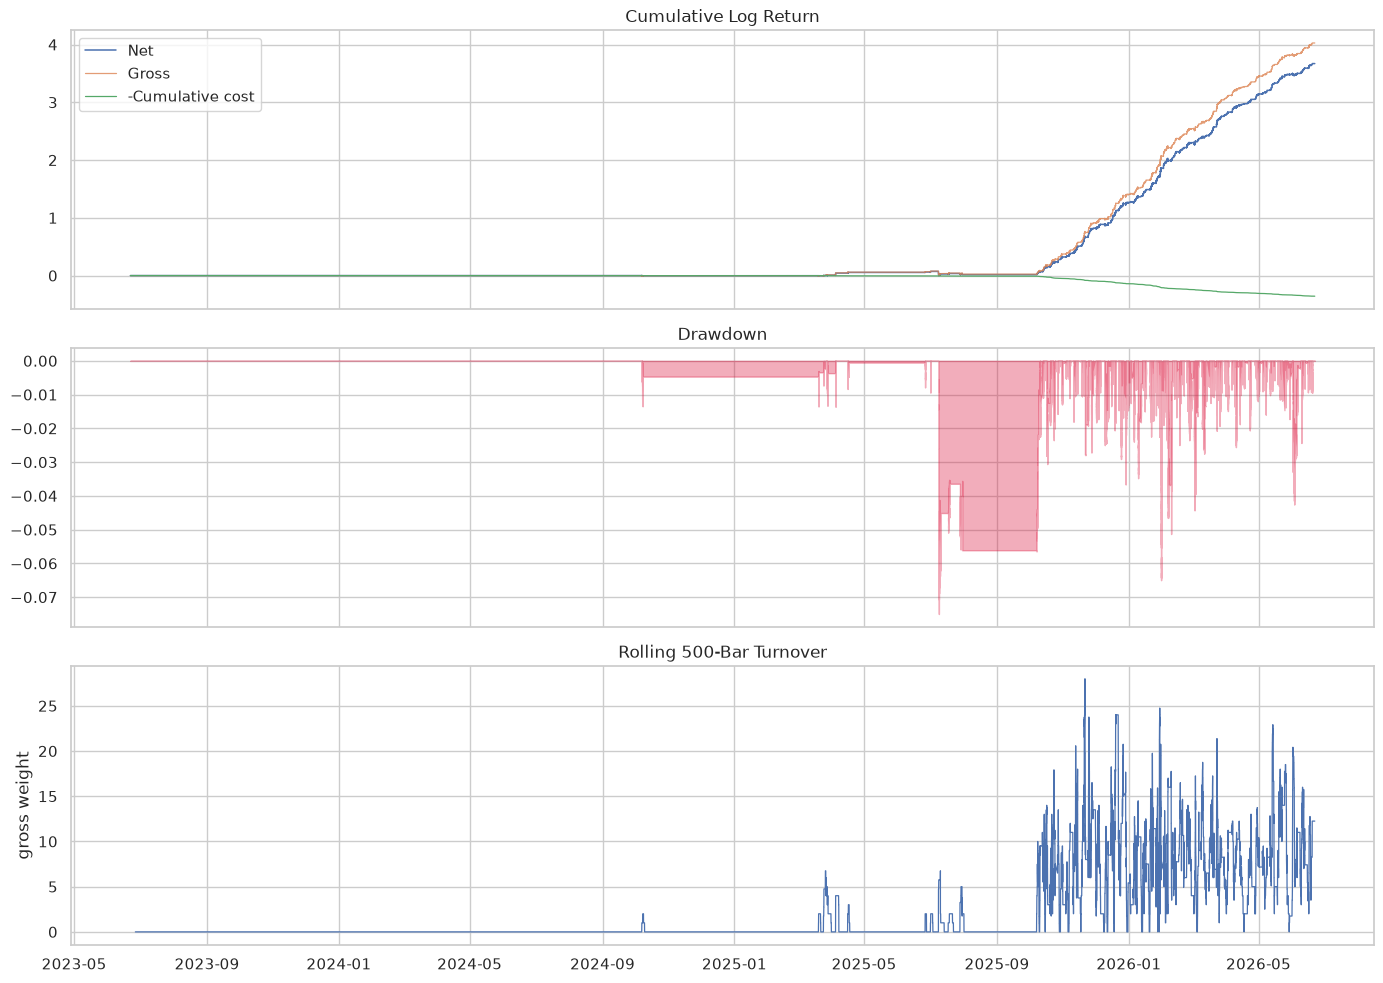

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(ts, selected_returns["equity"], label="Net", linewidth=1.1)
axes[0].plot(ts, selected_returns["gross_equity"], label="Gross", linewidth=0.9, alpha=0.8)
axes[0].plot(ts, -selected_returns["cost_equity"], label="-Cumulative cost", linewidth=0.9)
axes[0].set_title("Cumulative Log Return")
axes[0].legend(loc="upper left")

axes[1].fill_between(ts, selected_returns["drawdown"], 0, color="crimson", alpha=0.35)
axes[1].set_title("Drawdown")

axes[2].plot(ts, selected_returns["turnover"].rolling(500).sum(), linewidth=0.9)
axes[2].set_title("Rolling 500-Bar Turnover")
axes[2].set_ylabel("gross weight")
fig.tight_layout()
plt.show()

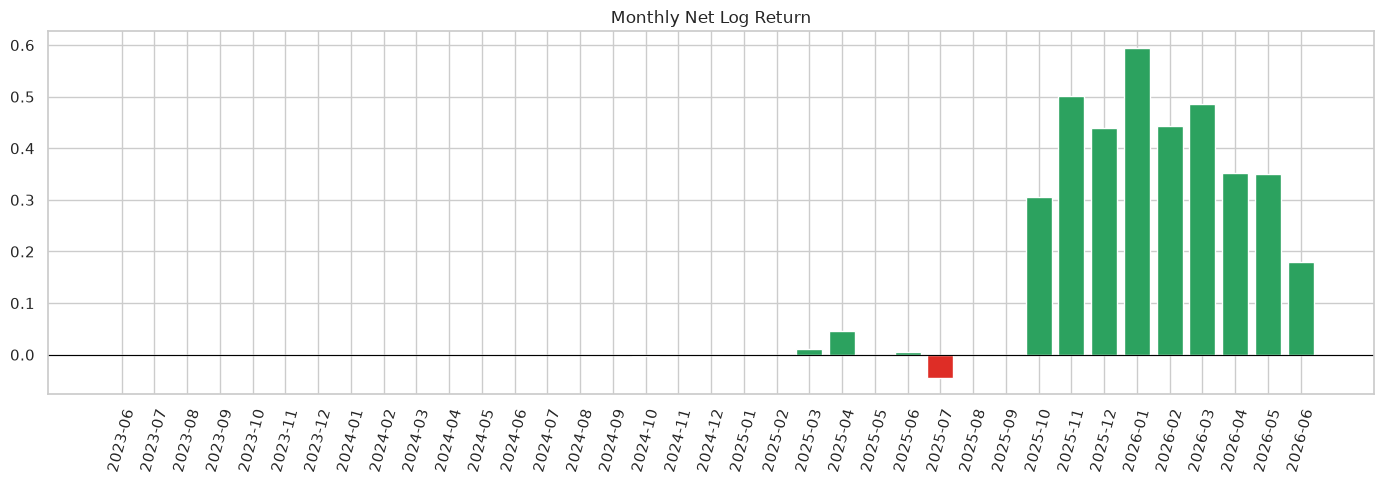

,month,gross_return,cost_return,net_return,turnover,active_bars,active
0,2023-06,0.000000,0.000000,0.000000,0.000000,0,False
1,2023-07,0.000000,0.000000,0.000000,0.000000,0,False
2,2023-08,0.000000,0.000000,0.000000,0.000000,0,False
3,2023-09,0.000000,0.000000,0.000000,0.000000,0,False
4,2023-10,0.000000,0.000000,0.000000,0.000000,0,False
5,2023-11,0.000000,0.000000,0.000000,0.000000,0,False
6,2023-12,0.000000,0.000000,0.000000,0.000000,0,False
7,2024-01,0.000000,0.000000,0.000000,0.000000,0,False
8,2024-02,0.000000,0.000000,0.000000,0.000000,0,False
9,2024-03,0.000000,0.000000,0.000000,0.000000,0,False


In [12]:
monthly = monthly_returns.copy()
monthly["active"] = monthly["active_bars"] > 0
fig, ax = plt.subplots(figsize=(14, 5))
colors = np.where(monthly["net_return"] >= 0, "#2ca25f", "#de2d26")
ax.bar(monthly["month"], monthly["net_return"], color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Monthly Net Log Return")
ax.tick_params(axis="x", rotation=75)
fig.tight_layout()
plt.show()

monthly

In [13]:
periods = {
    "pre_2025_06_22": ts < pd.Timestamp("2025-06-22T00:00:00Z"),
    "post_2025_06_22": ts >= pd.Timestamp("2025-06-22T00:00:00Z"),
    "2023": ts.dt.year == 2023,
    "2024": ts.dt.year == 2024,
    "2025": ts.dt.year == 2025,
    "2026": ts.dt.year == 2026,
}
rows = []
for label, mask in periods.items():
    sub = selected_returns.loc[mask]
    rows.append(
        {
            "period": label,
            "observations": len(sub),
            "active_bars": int(sub["active"].sum()),
            "gross_return": sub["gross_return"].sum(),
            "cost_return": sub["cost_return"].sum(),
            "net_return": sub["net_return"].sum(),
            "turnover": sub["turnover"].sum(),
        }
    )
pd.DataFrame(rows)

,period,observations,active_bars,gross_return,cost_return,net_return,turnover
0,pre_2025_06_22,126510,730,0.059426,0.004738,0.054688,21.750000
1,post_2025_06_22,115652,32916,3.967246,0.351779,3.615467,1505.416667
2,2023,25666,0,0.000000,0.000000,0.000000,0.000000
3,2024,64866,205,-0.002757,0.000704,-0.003461,2.000000
4,2025,95918,12407,1.407430,0.140664,1.266766,588.083333
5,2026,55712,21034,2.621999,0.215150,2.406849,937.083333


## Position And PnL Attribution

In [14]:
root_pnl = []
for root in ROOTS:
    root_pnl.append(
        {
            "root": root,
            "gross_return": selected_returns[f"{root}_gross_return"].sum(),
            "cost_return": selected_returns[f"{root}_cost_return"].sum(),
            "net_return": (
                selected_returns[f"{root}_gross_return"].sum()
                - selected_returns[f"{root}_cost_return"].sum()
            ),
            "mean_abs_position": positions[root].abs().mean(),
            "max_abs_position": positions[root].abs().max(),
        }
    )
root_pnl = pd.DataFrame(root_pnl)
root_pnl

,root,gross_return,cost_return,net_return,mean_abs_position,max_abs_position
0,GC,0.706727,0.015177,0.691550,0.024613,0.5
1,SI,0.633147,0.054730,0.578417,0.027182,0.5
2,HG,0.822639,0.025543,0.797096,0.026839,0.5
3,PL,0.874352,0.081862,0.792491,0.028210,0.5
4,PA,0.989807,0.179206,0.810601,0.032096,0.5


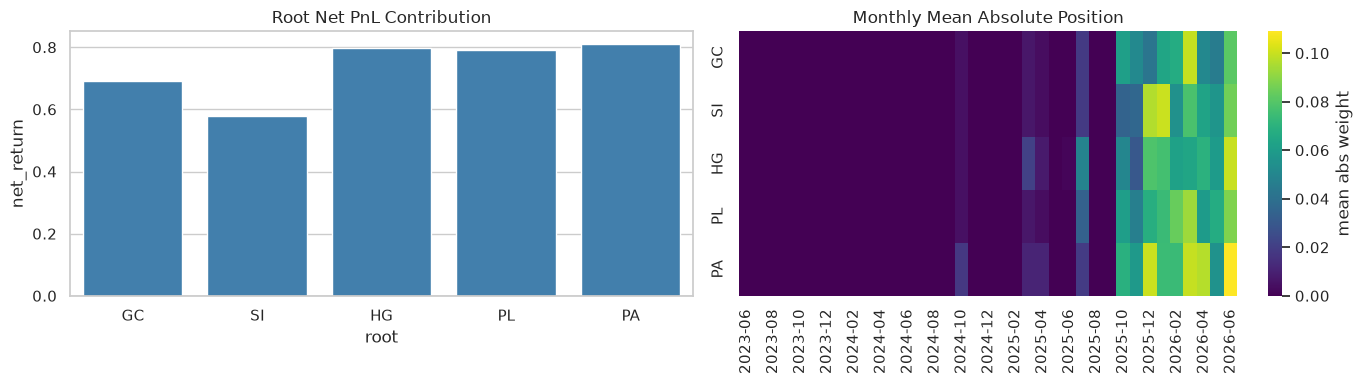

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=root_pnl, x="root", y="net_return", ax=axes[0], color="#3182bd")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Root Net PnL Contribution")

position_heat = positions.copy()
position_heat["month"] = month
monthly_pos = position_heat.groupby("month")[ROOTS].apply(lambda df: df.abs().mean())
sns.heatmap(monthly_pos.T, cmap="viridis", ax=axes[1], cbar_kws={"label": "mean abs weight"})
axes[1].set_title("Monthly Mean Absolute Position")
axes[1].set_xlabel("")
fig.tight_layout()
plt.show()

In [16]:
def position_event_counts(frame: pd.DataFrame) -> pd.DataFrame:
    prev = frame.shift(1).fillna(0.0)
    changed = (frame - prev).abs() > 1e-12
    entries = (prev.abs() <= 1e-12) & (frame.abs() > 1e-12)
    exits = (prev.abs() > 1e-12) & (frame.abs() <= 1e-12)
    flips = (prev * frame < 0) & changed
    return pd.DataFrame(
        {
            "changes": changed.sum(),
            "entries": entries.sum(),
            "exits": exits.sum(),
            "flips": flips.sum(),
        }
    )


print("Raw signal events")
display(position_event_counts(raw_positions))
print("Normalized portfolio weight events")
display(position_event_counts(positions))

Raw signal events


,changes,entries,exits,flips
GC,296,148,148,0
SI,360,179,179,2
HG,402,201,201,0
PL,429,213,213,3
PA,429,214,214,1


Normalized portfolio weight events


,changes,entries,exits,flips
GC,1546,640,640,25
SI,1533,613,613,44
HG,1535,628,628,28
PL,1540,600,600,49
PA,1525,608,608,35


## Flow Filters And Signal State

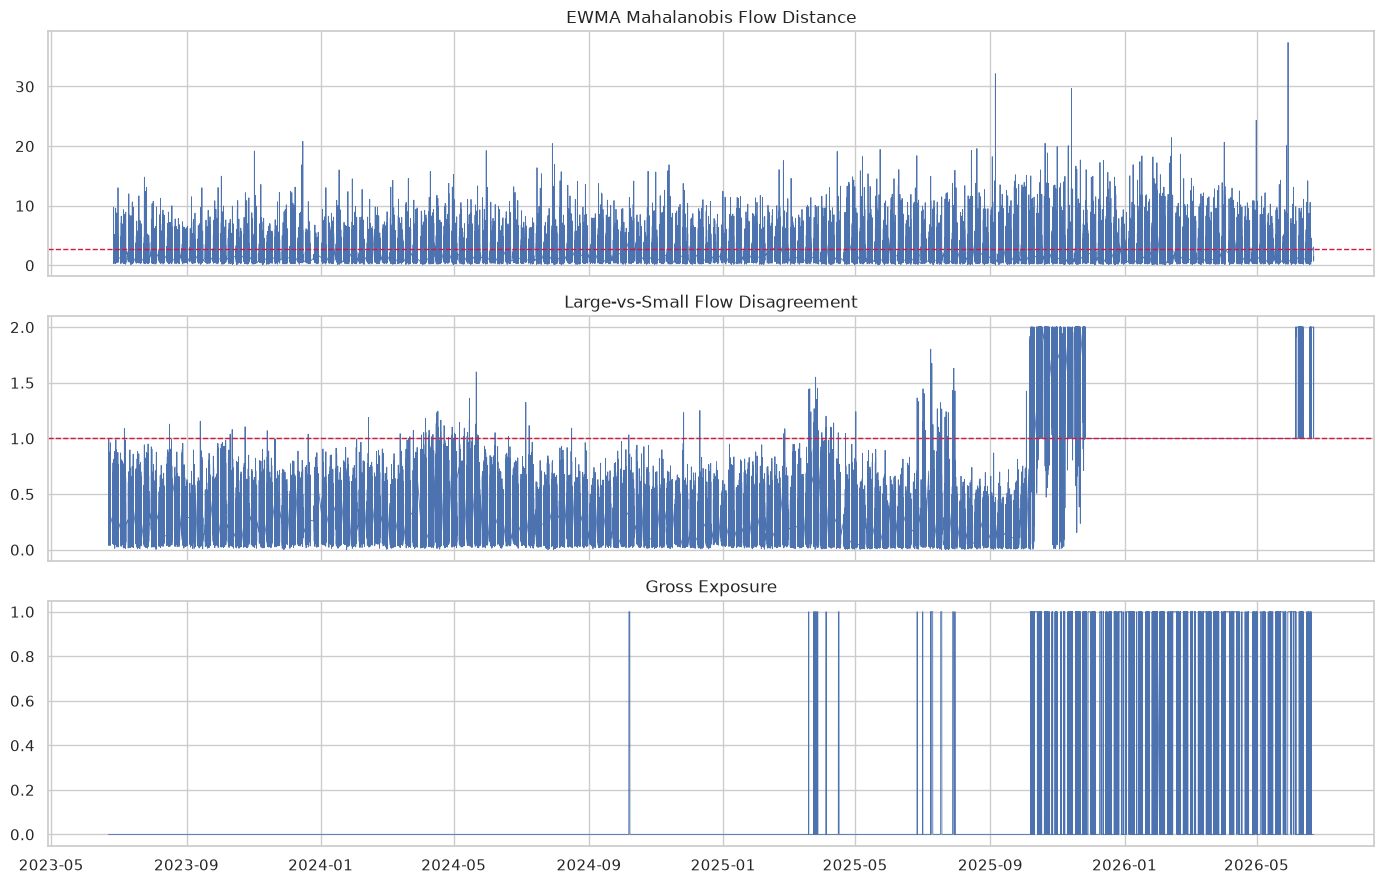

In [17]:
md_threshold = summary["md_threshold"]
disagreement_threshold = summary["large_small_l1_threshold"]

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
axes[0].plot(ts, anomalies["md_rolling"], linewidth=0.6)
axes[0].axhline(md_threshold, color="crimson", linestyle="--", linewidth=1)
axes[0].set_title("EWMA Mahalanobis Flow Distance")

axes[1].plot(ts, size_disagreement["large_small_l1_distance"], linewidth=0.6)
axes[1].axhline(disagreement_threshold, color="crimson", linestyle="--", linewidth=1)
axes[1].set_title("Large-vs-Small Flow Disagreement")

axes[2].plot(ts, positions.abs().sum(axis=1), linewidth=0.6)
axes[2].set_title("Gross Exposure")
fig.tight_layout()
plt.show()

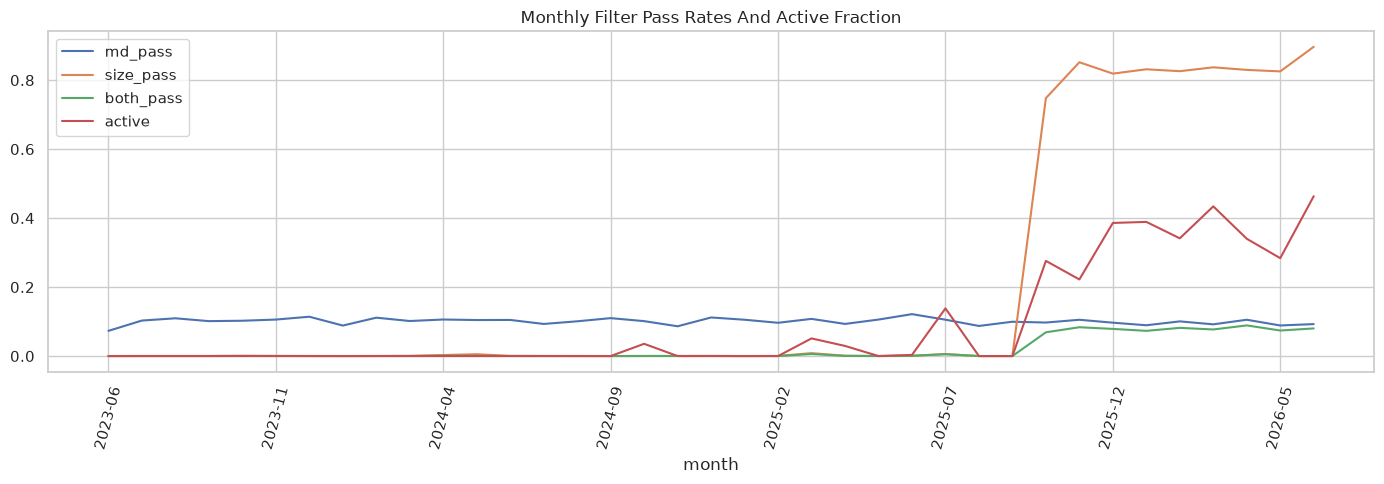

,md_pass,size_pass,both_pass,active
month,,,,
2025-01,0.105263,0.000000,0.000000,0.000000
2025-02,0.096433,0.000377,0.000000,0.000000
2025-03,0.107754,0.008373,0.005825,0.051147
2025-04,0.093138,0.000961,0.000481,0.029323
2025-05,0.105761,0.000137,0.000000,0.000000
2025-06,0.121507,0.000747,0.000747,0.003288
2025-07,0.105389,0.005689,0.005389,0.138174
2025-08,0.087240,0.000000,0.000000,0.000000
2025-09,0.099510,0.000000,0.000000,0.000000


In [18]:
filter_frame = pd.DataFrame(
    {
        "month": month,
        "md_pass": anomalies["md_rolling"] >= md_threshold,
        "size_pass": size_disagreement["large_small_l1_distance"] >= disagreement_threshold,
        "both_pass": (
            (anomalies["md_rolling"] >= md_threshold)
            & (size_disagreement["large_small_l1_distance"] >= disagreement_threshold)
        ),
        "active": selected_returns["active"],
    }
)
filter_monthly = filter_frame.groupby("month").mean(numeric_only=True)
fig, ax = plt.subplots(figsize=(14, 5))
filter_monthly[["md_pass", "size_pass", "both_pass", "active"]].plot(ax=ax)
ax.set_title("Monthly Filter Pass Rates And Active Fraction")
ax.tick_params(axis="x", rotation=75)
fig.tight_layout()
plt.show()
filter_monthly.tail(18)

## Forward Return Helpers

In [19]:
def future_returns(frame: pd.DataFrame, horizons: list[int]) -> dict[int, pd.DataFrame]:
    out = {}
    for horizon in horizons:
        fut = sum(frame.shift(-step) for step in range(1, horizon + 1))
        out[horizon] = fut
    return out


future_by_horizon = future_returns(returns[ROOTS], HORIZONS)
applied_positions = positions.shift(1).fillna(0.0)
portfolio_future = pd.DataFrame(
    {horizon: (applied_positions * future_by_horizon[horizon]).sum(axis=1) for horizon in HORIZONS}
)

portfolio_signal = pd.DataFrame(
    {
        "convergence_score": (positions * (-residual_z[ROOTS])).sum(axis=1),
        "signal_strength": (positions.abs() * residual_z[ROOTS].abs()).sum(axis=1),
        "gross_exposure": positions.abs().sum(axis=1),
        "md": anomalies["md_rolling"],
        "large_small_l1": size_disagreement["large_small_l1_distance"],
        "active": selected_returns["active"],
        "month": month,
    }
)
portfolio_signal.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,50%,95%,99%,max
convergence_score,242162.0,0.165346,0.469863,-0.638782,0.000000,0.000000,0.000000,1.317697,2.173070,10.736431
signal_strength,242162.0,0.189723,0.515524,0.000000,0.000000,0.000000,0.000000,1.478353,2.244747,10.736431
gross_exposure,242162.0,0.138940,0.345885,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
md,241662.0,1.647210,1.169058,0.037083,0.427730,0.642032,1.337395,3.685297,6.344876,37.374737
large_small_l1,242162.0,0.562581,0.508305,0.000000,0.033526,0.065011,0.308421,1.747452,2.000000,2.000000


## Portfolio-Level Signal Vs Forward Returns

`convergence_score = sum(position_i * -residual_z_i)`.

For a mean-reversion portfolio, higher positive values mean the held book is more
aligned with residual convergence. The y-axis is the realized forward return of
the currently held portfolio over the given horizon.

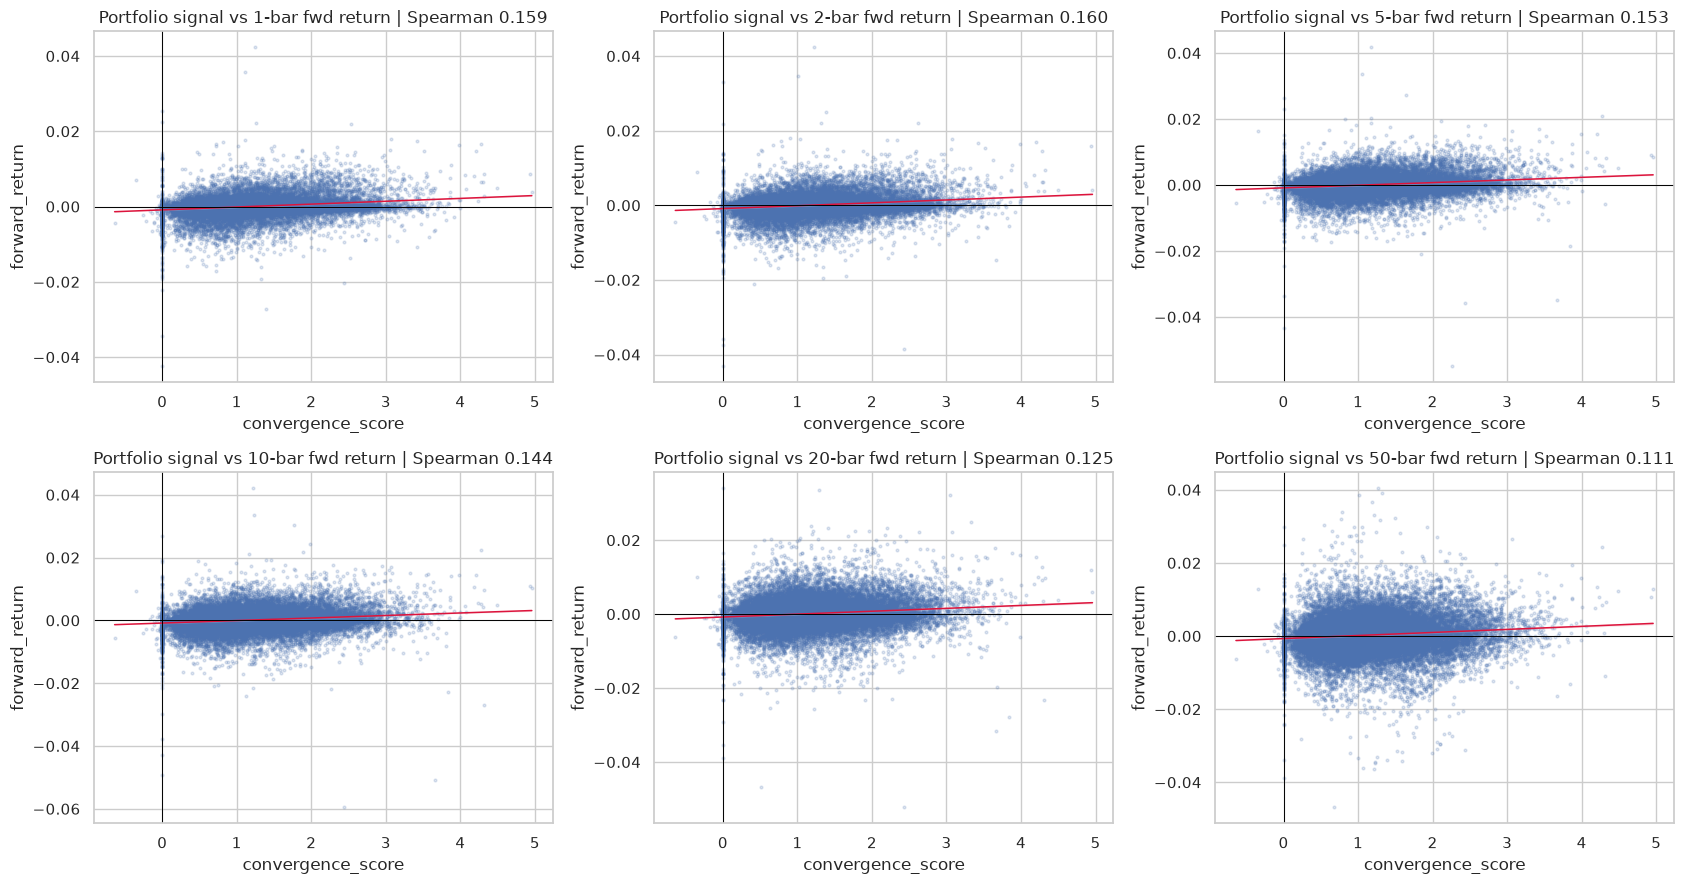

In [20]:
def sample_frame(frame: pd.DataFrame, max_rows: int = 40_000) -> pd.DataFrame:
    clean = frame.replace([np.inf, -np.inf], np.nan).dropna()
    if len(clean) <= max_rows:
        return clean
    idx = RNG.choice(clean.index.to_numpy(), size=max_rows, replace=False)
    return clean.loc[idx].sort_index()


fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, horizon in zip(axes.ravel(), HORIZONS, strict=True):
    frame = portfolio_signal.assign(forward_return=portfolio_future[horizon])
    frame = frame.loc[frame["active"]].copy()
    plot_df = sample_frame(frame[["convergence_score", "forward_return"]], 35_000)
    sns.regplot(
        data=plot_df,
        x="convergence_score",
        y="forward_return",
        scatter_kws={"s": 4, "alpha": 0.18},
        line_kws={"color": "crimson", "linewidth": 1.1},
        ax=ax,
    )
    corr = plot_df["convergence_score"].corr(plot_df["forward_return"], method="spearman")
    ax.axhline(0, color="black", linewidth=0.7)
    ax.axvline(0, color="black", linewidth=0.7)
    ax.set_title(f"Portfolio signal vs {horizon}-bar fwd return | Spearman {corr:.3f}")
fig.tight_layout()
plt.show()

In [21]:
portfolio_scatter_stats = []
for horizon in HORIZONS:
    frame = portfolio_signal.assign(forward_return=portfolio_future[horizon])
    frame = frame.loc[frame["active"], ["convergence_score", "signal_strength", "forward_return"]]
    frame = frame.replace([np.inf, -np.inf], np.nan).dropna()
    for signal in ["convergence_score", "signal_strength"]:
        portfolio_scatter_stats.append(
            {
                "signal": signal,
                "horizon": horizon,
                "observations": len(frame),
                "spearman": frame[signal].corr(frame["forward_return"], method="spearman"),
                "pearson": frame[signal].corr(frame["forward_return"], method="pearson"),
                "mean_forward_bps": frame["forward_return"].mean() * 10_000,
            }
        )
pd.DataFrame(portfolio_scatter_stats)

,signal,horizon,observations,spearman,pearson,mean_forward_bps
0,convergence_score,1,33646,0.158608,0.206467,0.106138
1,signal_strength,1,33646,0.145720,0.209262,0.106138
2,convergence_score,2,33646,0.159904,0.197253,0.186001
3,signal_strength,2,33646,0.147404,0.201274,0.186001
4,convergence_score,5,33646,0.152951,0.182286,0.413386
5,signal_strength,5,33646,0.142848,0.185706,0.413386
6,convergence_score,10,33646,0.143819,0.160133,0.852565
7,signal_strength,10,33646,0.134923,0.163325,0.852565
8,convergence_score,20,33646,0.124615,0.131858,1.307417
9,signal_strength,20,33646,0.120711,0.137478,1.307417


## Flow Filter Values Vs Portfolio Forward Returns

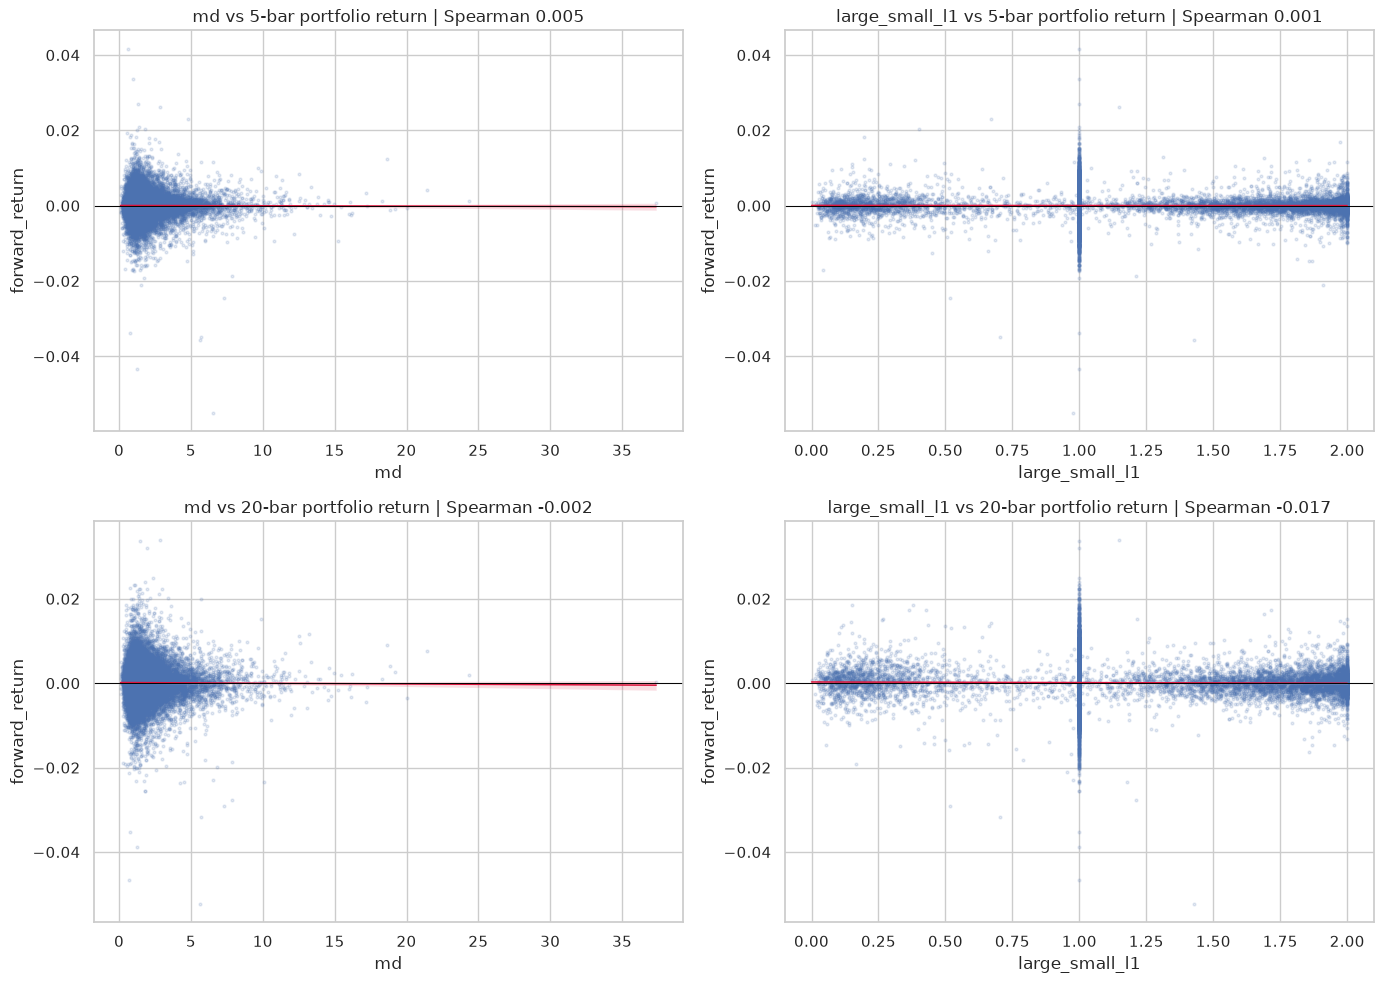

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, signal, horizon in [
    (axes[0, 0], "md", 5),
    (axes[0, 1], "large_small_l1", 5),
    (axes[1, 0], "md", 20),
    (axes[1, 1], "large_small_l1", 20),
]:
    frame = portfolio_signal.assign(forward_return=portfolio_future[horizon])
    frame = frame.loc[frame["active"], [signal, "forward_return"]]
    plot_df = sample_frame(frame, 35_000)
    sns.regplot(
        data=plot_df,
        x=signal,
        y="forward_return",
        scatter_kws={"s": 4, "alpha": 0.15},
        line_kws={"color": "crimson", "linewidth": 1.1},
        ax=ax,
    )
    corr = plot_df[signal].corr(plot_df["forward_return"], method="spearman")
    ax.axhline(0, color="black", linewidth=0.7)
    ax.set_title(f"{signal} vs {horizon}-bar portfolio return | Spearman {corr:.3f}")
fig.tight_layout()
plt.show()

## Individual Root Signal Vs Forward Returns

Root-level directional signal is `-residual_z`. If residual mean reversion is
working, the slope should be positive: cheap assets (`-z > 0`) should have
positive forward returns, and rich assets (`-z < 0`) should have negative
forward returns.

In [23]:
root_scatter_stats = []
for root in ROOTS:
    signal = -residual_z[root]
    active_root = raw_positions[root].abs() > 0
    for horizon in HORIZONS:
        fwd = future_by_horizon[horizon][root]
        frame = (
            pd.DataFrame(
                {
                    "root": root,
                    "signal": signal,
                    "forward_return": fwd,
                    "active_root": active_root,
                }
            )
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )
        for sample_name, sample_mask in {
            "all": np.ones(len(frame), dtype=bool),
            "active_root": frame["active_root"].to_numpy(dtype=bool),
        }.items():
            sub = frame.loc[sample_mask]
            if len(sub) == 0:
                continue
            root_scatter_stats.append(
                {
                    "root": root,
                    "sample": sample_name,
                    "horizon": horizon,
                    "observations": len(sub),
                    "spearman": sub["signal"].corr(sub["forward_return"], method="spearman"),
                    "pearson": sub["signal"].corr(sub["forward_return"], method="pearson"),
                    "mean_forward_bps": sub["forward_return"].mean() * 10_000,
                }
            )
root_scatter_stats = pd.DataFrame(root_scatter_stats)
root_scatter_stats.sort_values(["sample", "root", "horizon"])

,root,sample,horizon,observations,spearman,pearson,mean_forward_bps
1,GC,active_root,1,7121,0.100860,0.186065,-0.270571
3,GC,active_root,2,7121,0.104105,0.181596,-0.502856
5,GC,active_root,5,7121,0.107128,0.175055,-1.027940
7,GC,active_root,10,7121,0.103848,0.156260,-2.250585
9,GC,active_root,20,7121,0.102755,0.140778,-5.049649
11,GC,active_root,50,7120,0.133156,0.171041,-8.506173
25,HG,active_root,1,9133,0.097724,0.146132,-0.147009
27,HG,active_root,2,9133,0.104295,0.143383,-0.154967
29,HG,active_root,5,9133,0.105009,0.128057,0.024066
31,HG,active_root,10,9133,0.111692,0.106809,0.279916


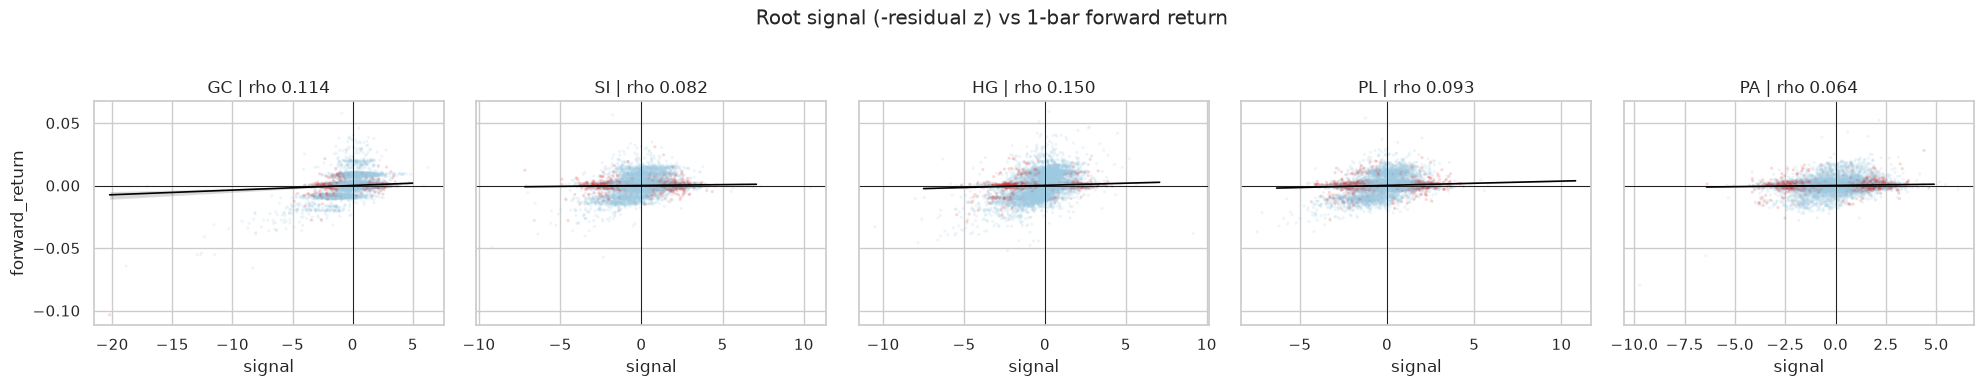

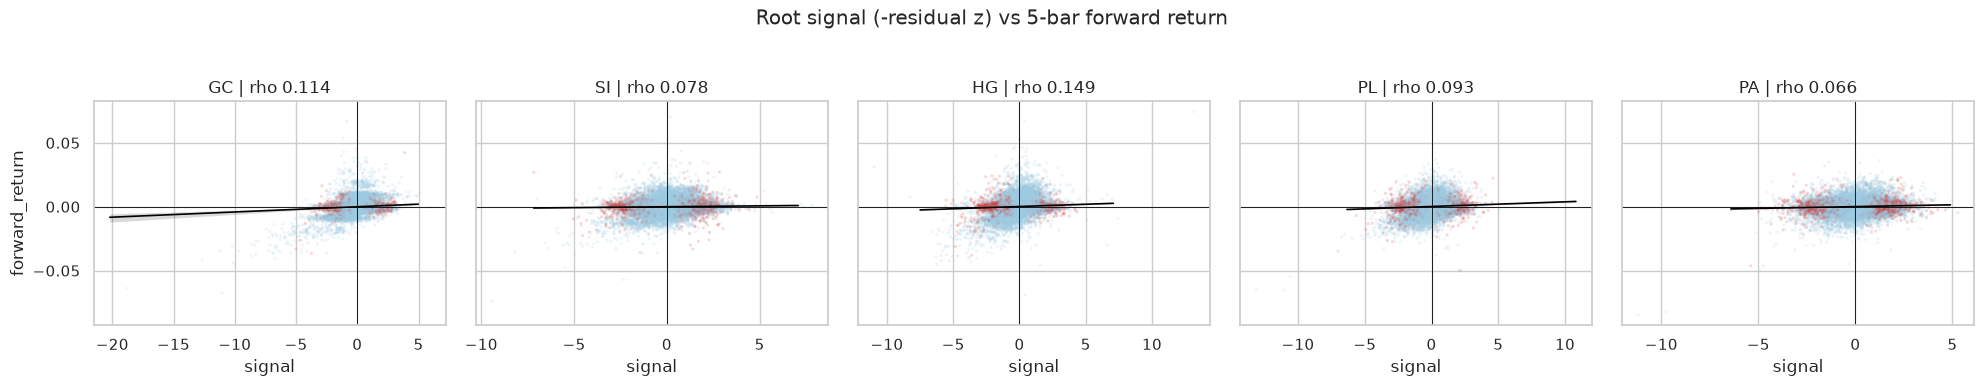

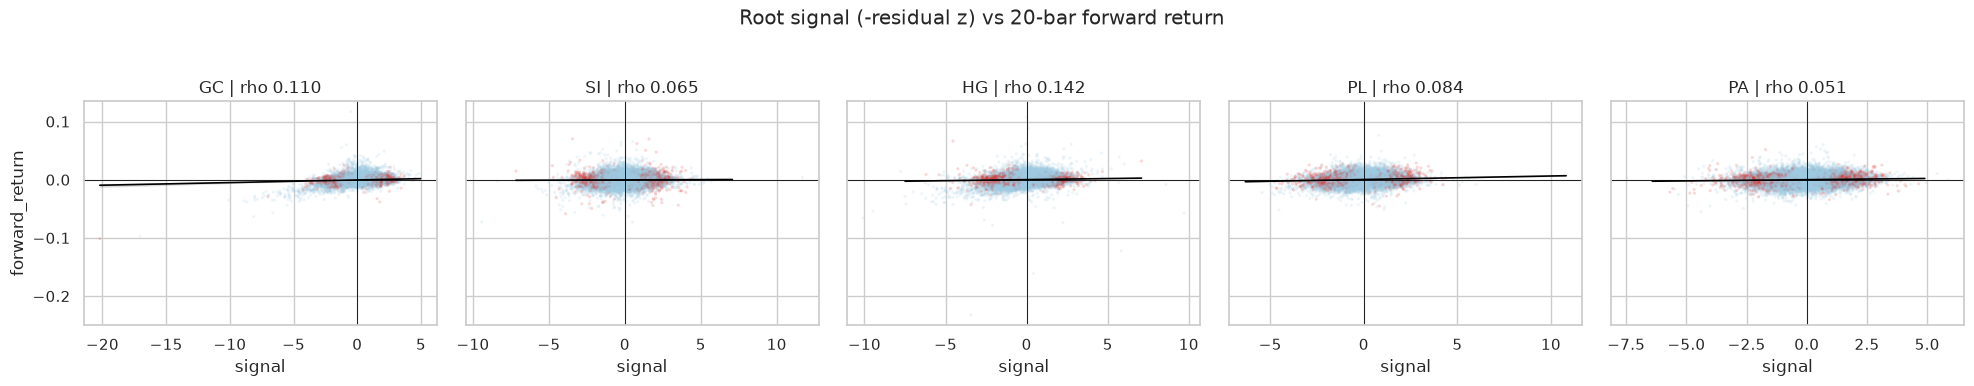

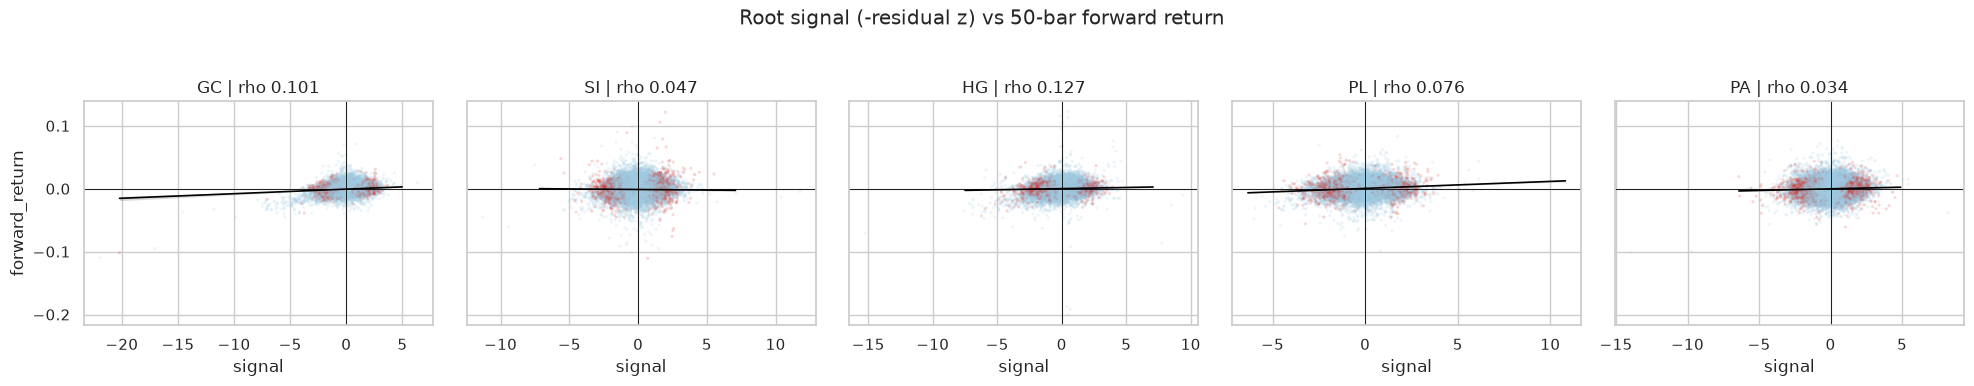

In [24]:
for horizon in [1, 5, 20, 50]:
    fig, axes = plt.subplots(1, len(ROOTS), figsize=(20, 3.7), sharey=True)
    for ax, root in zip(axes, ROOTS, strict=True):
        frame = (
            pd.DataFrame(
                {
                    "signal": -residual_z[root],
                    "forward_return": future_by_horizon[horizon][root],
                    "active_root": raw_positions[root].abs() > 0,
                }
            )
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )
        plot_df = sample_frame(frame, 25_000)
        sns.scatterplot(
            data=plot_df,
            x="signal",
            y="forward_return",
            hue="active_root",
            palette={False: "#9ecae1", True: "#de2d26"},
            s=5,
            alpha=0.18,
            linewidth=0,
            ax=ax,
            legend=False,
        )
        active = frame.loc[frame["active_root"]]
        if len(active) > 30:
            active_plot = sample_frame(active[["signal", "forward_return"]], 15_000)
            sns.regplot(
                data=active_plot,
                x="signal",
                y="forward_return",
                scatter=False,
                line_kws={"color": "black", "linewidth": 1.2},
                ax=ax,
            )
        corr = frame["signal"].corr(frame["forward_return"], method="spearman")
        ax.axhline(0, color="black", linewidth=0.6)
        ax.axvline(0, color="black", linewidth=0.6)
        ax.set_title(f"{root} | rho {corr:.3f}")
    fig.suptitle(f"Root signal (-residual z) vs {horizon}-bar forward return", y=1.04)
    fig.tight_layout()
    plt.show()

## Root-Level Active Position Signal Vs Forward Returns

This view conditions on root sleeves that were actually active. The x-axis is
`position_i * forward_return_i` signal alignment proxy before realization:
`position_i * expected_direction_i`, where expected direction is `-residual_z_i`.
The y-axis is realized root-level forward return multiplied by the current root
position, so positive y means that root sleeve contributed positively over the
horizon before costs.

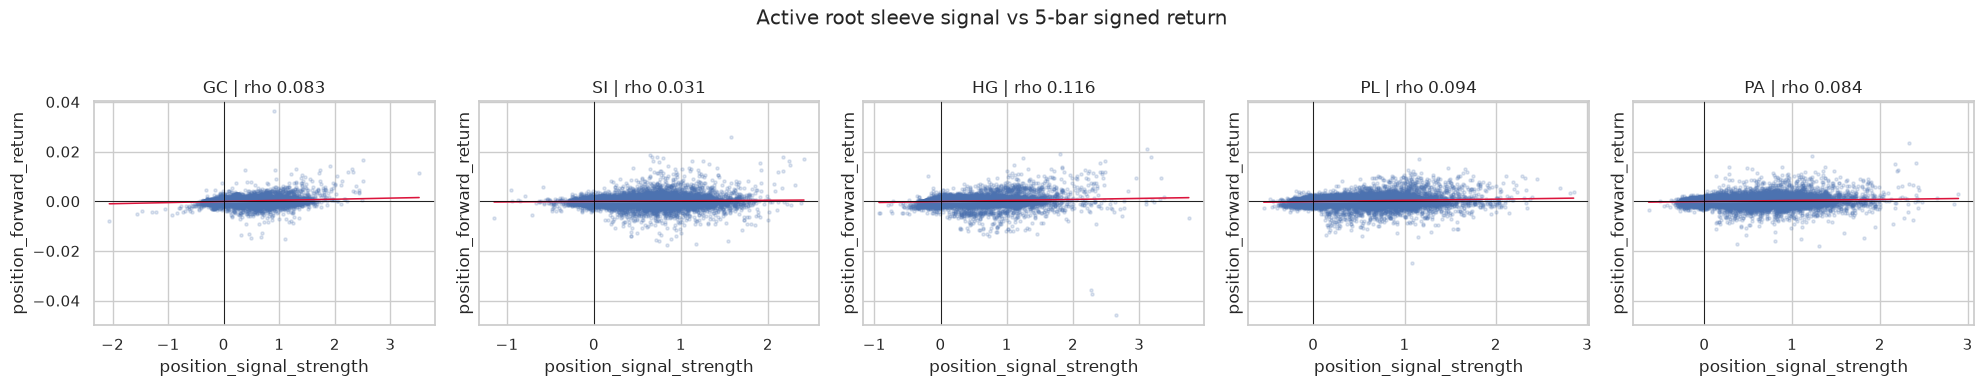

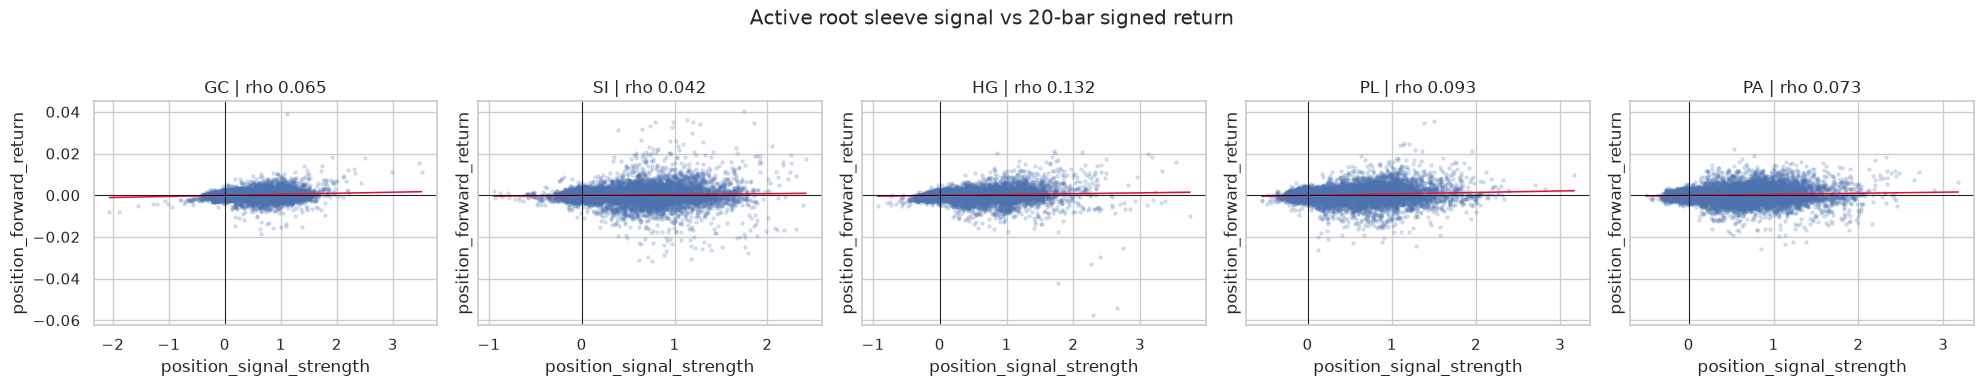

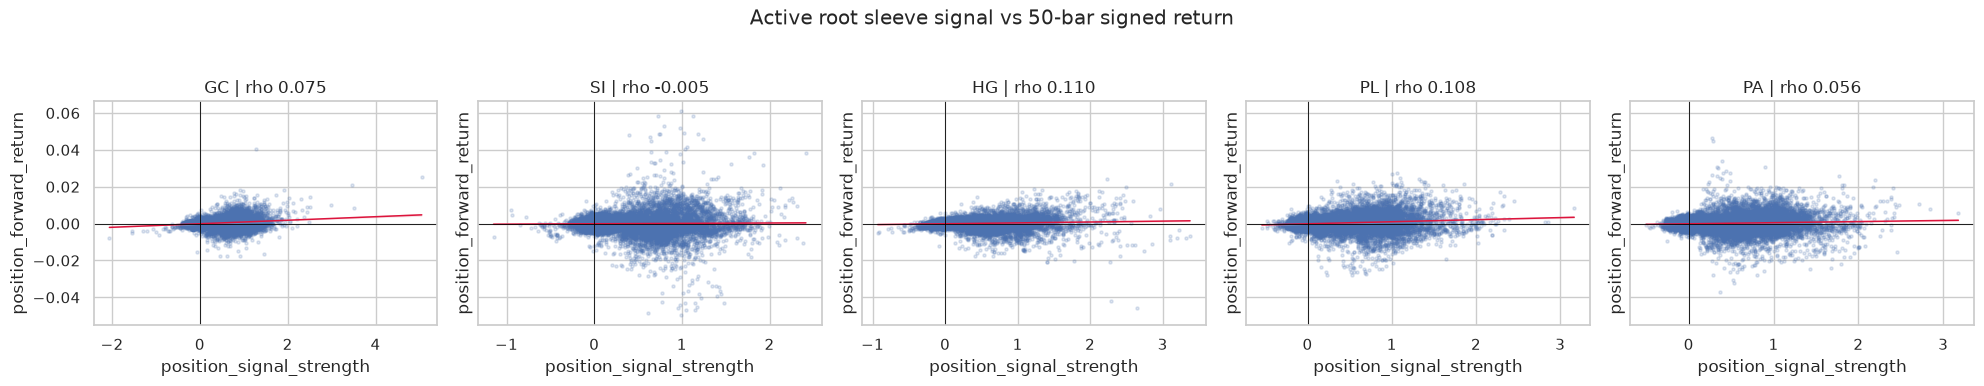

In [25]:
for horizon in [5, 20, 50]:
    fig, axes = plt.subplots(1, len(ROOTS), figsize=(20, 3.7), sharey=True)
    for ax, root in zip(axes, ROOTS, strict=True):
        frame = (
            pd.DataFrame(
                {
                    "position_signal_strength": positions[root] * (-residual_z[root]),
                    "position_forward_return": positions[root] * future_by_horizon[horizon][root],
                    "active_root": positions[root].abs() > 0,
                }
            )
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )
        frame = frame.loc[frame["active_root"]]
        plot_df = sample_frame(frame, 20_000)
        if plot_df.empty:
            ax.set_title(f"{root} | no active obs")
            continue
        sns.regplot(
            data=plot_df,
            x="position_signal_strength",
            y="position_forward_return",
            scatter_kws={"s": 5, "alpha": 0.18},
            line_kws={"color": "crimson", "linewidth": 1.1},
            ax=ax,
        )
        corr = plot_df["position_signal_strength"].corr(
            plot_df["position_forward_return"], method="spearman"
        )
        ax.axhline(0, color="black", linewidth=0.6)
        ax.axvline(0, color="black", linewidth=0.6)
        ax.set_title(f"{root} | rho {corr:.3f}")
    fig.suptitle(f"Active root sleeve signal vs {horizon}-bar signed return", y=1.04)
    fig.tight_layout()
    plt.show()

## Decile Forward Return Tables

In [26]:
def decile_table(signal: pd.Series, forward: pd.Series, bins: int = 10) -> pd.DataFrame:
    frame = pd.DataFrame({"signal": signal, "forward_return": forward})
    frame = frame.replace([np.inf, -np.inf], np.nan).dropna()
    ranks = frame["signal"].rank(method="first")
    frame["decile"] = pd.qcut(ranks, bins, labels=False, duplicates="drop") + 1
    return frame.groupby("decile", as_index=False).agg(
        observations=("forward_return", "size"),
        mean_bps=("forward_return", lambda x: x.mean() * 10_000),
        median_bps=("forward_return", lambda x: x.median() * 10_000),
        hit_rate=("forward_return", lambda x: (x > 0).mean()),
    )


portfolio_deciles = []
for horizon in HORIZONS:
    frame = portfolio_signal.loc[portfolio_signal["active"]]
    table = decile_table(frame["convergence_score"], portfolio_future.loc[frame.index, horizon])
    table.insert(0, "horizon", horizon)
    portfolio_deciles.append(table)
portfolio_deciles = pd.concat(portfolio_deciles, ignore_index=True)
portfolio_deciles

,horizon,decile,observations,mean_bps,median_bps,hit_rate
0,1,1,3365,-9.059747,-2.957846,0.370579
1,1,2,3365,-3.014762,-0.612840,0.467162
2,1,3,3364,-2.338161,-0.364352,0.479489
3,1,4,3365,-1.592954,-0.219909,0.487073
4,1,5,3364,0.049680,0.098416,0.505945
5,1,6,3365,1.157678,0.431646,0.523923
6,1,7,3364,1.314715,0.365314,0.521106
7,1,8,3365,1.742231,0.470147,0.534027
8,1,9,3364,3.212440,1.045387,0.548157
9,1,10,3365,9.590797,2.390312,0.589599


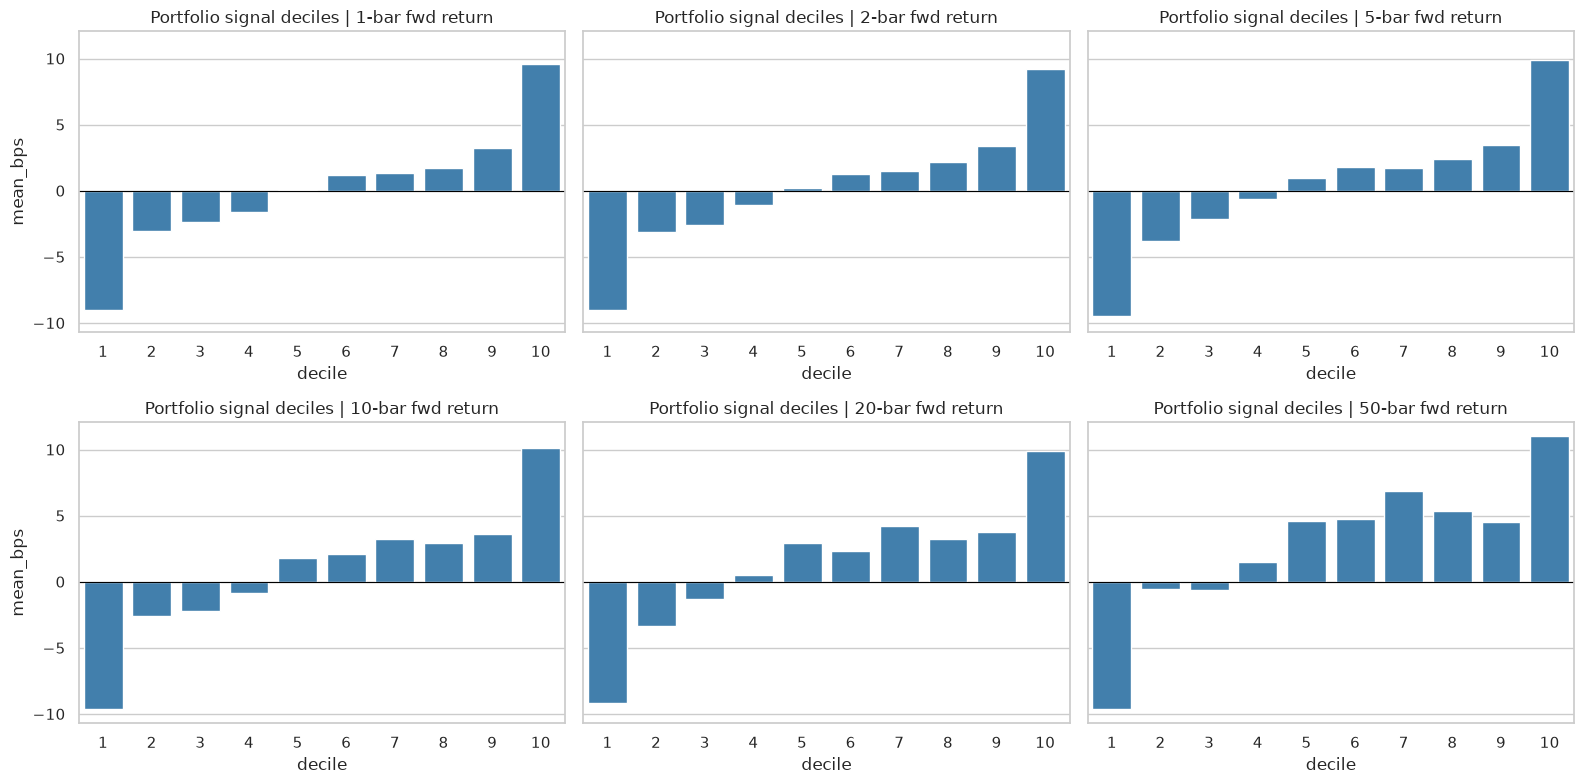

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey=True)
for ax, horizon in zip(axes.ravel(), HORIZONS, strict=True):
    sub = portfolio_deciles.loc[portfolio_deciles["horizon"] == horizon]
    sns.barplot(data=sub, x="decile", y="mean_bps", ax=ax, color="#3182bd")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"Portfolio signal deciles | {horizon}-bar fwd return")
fig.tight_layout()
plt.show()

## Information Coefficients

In [28]:
ic_fdr.assign(abs_ic=ic_fdr["spearman_ic"].abs()).sort_values("abs_ic", ascending=False).head(30)

,feature,root,horizon,spearman_ic,pvalue,observations,bh_qvalue,abs_ic
73,rv_z_HG,HG,2,-0.150507,0.000000e+00,240161,0.000000e+00,0.150507
72,rv_z_HG,HG,1,-0.149749,0.000000e+00,240162,0.000000e+00,0.149749
74,rv_z_HG,HG,5,-0.148656,0.000000e+00,240158,0.000000e+00,0.148656
75,rv_z_HG,HG,10,-0.147427,0.000000e+00,240153,0.000000e+00,0.147427
76,rv_z_HG,HG,20,-0.142251,0.000000e+00,240143,0.000000e+00,0.142251
77,rv_z_HG,HG,50,-0.127143,0.000000e+00,240113,0.000000e+00,0.127143
2,rv_z_GC,GC,5,-0.114173,0.000000e+00,240158,0.000000e+00,0.114173
0,rv_z_GC,GC,1,-0.114124,0.000000e+00,240162,0.000000e+00,0.114124
1,rv_z_GC,GC,2,-0.112996,0.000000e+00,240161,0.000000e+00,0.112996
3,rv_z_GC,GC,10,-0.111583,0.000000e+00,240153,0.000000e+00,0.111583


In [29]:
monthly_ic_summary = monthly_ic.groupby("root")["spearman_ic"].agg(["mean", "std", "count"])
monthly_ic_summary

,mean,std,count
root,,,
GC,-0.001792,0.042817,1024
HG,-0.002720,0.045702,1024
PA,0.000885,0.035177,1024
PL,-0.000160,0.041031,1024
SI,0.001109,0.039283,1024


## Interpretation Checklist

Use this section while reviewing the plots above.

- The strategy passes the full-sample cost gate, including the 3x cost stress.
- The strongest direct predictive signal remains residual mean reversion: `rv_z`
  has negative IC versus future root returns, so `-rv_z` should slope positive in
  the root-level scatterplots.
- Portfolio-level scatterplots should be read on active observations only,
  because inactive bars have no trading exposure.
- The monthly attribution table is essential: most PnL occurs in the late-2025
  and 2026 active regime, while the older incremental window is only mildly
  positive and trades infrequently.
- The next robustness step is to isolate why the filters activate much more in
  late 2025/2026 and test whether the same state can be recognized ex ante.